# Predicting Potential Spammers on Fiverr

**Supervised machine learning, binary classification** | Kaggle: *Predict Potential Spammers on Fiverr*

**Goal.** Use the steps a new user takes on Fiverr to predict which users will become spammers (`label` = 1).
**Data.** 458,798 users, 51 anonymised behaviour features (`X1` to `X51`), `user_id` and `label`. Only about 2.7% of users are spammers, so accuracy is a misleading metric; models are compared mainly on **PR-AUC**.

| Section | Content |
|---|---|
| 0 | Setup and imports |
| 1 | Data description |
| 2 | Data cleaning |
| 3 | Exploratory data analysis (EDA) |
| 4 | Distributions, skewness and transformation |
| 5 | Outliers and feature scaling |
| 6 | Encoding, feature engineering and train/validation/test split |
| 7 | Model building and comparison |
| 8 | Overfitting analysis and treatment |
| 9 | Hyperparameter tuning, final model and test evaluation |
| 10 | Threshold trade-off, saving the model, and files for the Streamlit app |
| 11 | Conclusion |

**Run order.** Run the notebook top to bottom. Section 9 contains a Random Forest search that takes about 42 minutes; lower `n_iter` or skip it if you are short on time.
**Required libraries.** pandas, numpy, matplotlib, seaborn, scikit-learn, xgboost, lightgbm, joblib.
**Data file.** `fiverr_data.csv` (the labeled Kaggle data) must be in the same folder.

## 0. Setup and imports

**Why:** all libraries are imported once at the top so the notebook is reproducible. `RANDOM_STATE = 42` is used everywhere so results can be repeated.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib, json
import time

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_recall_curve,
                             precision_score, recall_score, f1_score)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC

from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

RANDOM_STATE = 42

## 1. Data description

**Why:** before cleaning or modelling we need the size, column types, summary statistics and target balance of the data.
**How:** `head`, `columns`, `shape`, `info` and `describe`.
**What we found:** 458,798 rows and 53 columns (`label`, `user_id`, `X1` to `X51`, all numeric). The mean of `label` is 0.0269, i.e. **2.69% spammers**. Several columns (`X27`, `X29`, `X30`, `X33`, `X46` to `X48`) have a standard deviation of 0 (constant). Only `X13` has missing values.

In [2]:
df = pd.read_csv("fiverr_data.csv")
df.head()

,label,user_id,X1,X2,X3,X4,X5,X6,X7,X8,...,X42,X43,X44,X45,X46,X47,X48,X49,X50,X51
0,0,1,20972,14,13,3,11,1,2,15,...,0,0,0,0,0,0,0,0,1,0
1,0,2,7362,213,71,3,11,1,2,15,...,0,0,0,0,0,0,0,0,0,0
2,0,3,21216,215,71,3,11,1,2,15,...,0,0,0,0,0,0,0,0,0,0
3,0,4,2261,212,71,2,8,1,2,15,...,0,0,0,0,0,0,0,1,0,0
4,0,5,4543,213,71,2,8,1,2,15,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.columns

Index(['label', 'user_id', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8',
       'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18',
       'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X27', 'X28',
       'X29', 'X30', 'X31', 'X32', 'X33', 'X34', 'X35', 'X36', 'X37', 'X38',
       'X39', 'X40', 'X41', 'X42', 'X43', 'X44', 'X45', 'X46', 'X47', 'X48',
       'X49', 'X50', 'X51'],
      dtype='str')

In [4]:
df.shape

(458798, 53)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 458798 entries, 0 to 458797
Data columns (total 53 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   label    458798 non-null  int64  
 1   user_id  458798 non-null  int64  
 2   X1       458798 non-null  int64  
 3   X2       458798 non-null  int64  
 4   X3       458798 non-null  int64  
 5   X4       458798 non-null  int64  
 6   X5       458798 non-null  int64  
 7   X6       458798 non-null  int64  
 8   X7       458798 non-null  int64  
 9   X8       458798 non-null  int64  
 10  X9       458798 non-null  int64  
 11  X10      458798 non-null  int64  
 12  X11      458798 non-null  int64  
 13  X12      458798 non-null  int64  
 14  X13      458792 non-null  float64
 15  X14      458798 non-null  int64  
 16  X15      458798 non-null  int64  
 17  X16      458798 non-null  int64  
 18  X17      458798 non-null  int64  
 19  X18      458798 non-null  int64  
 20  X19      458798 non-null  int64  
 21

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
label,458798.0,0.026855,0.161660,0.0,0.00,0.0,0.00,1.0
user_id,458798.0,241363.771411,139440.017203,1.0,120595.25,241234.5,362157.75,482935.0
X1,458798.0,10850.591243,7078.656632,1.0,4692.00,11574.0,16425.00,24234.0
X2,458798.0,154.947696,67.952267,1.0,95.00,189.0,213.00,222.0
X3,458798.0,28.107965,19.227303,1.0,13.00,14.0,37.00,94.0
X4,458798.0,2.407831,0.800163,1.0,2.00,3.0,3.00,3.0
X5,458798.0,10.985176,5.527487,1.0,8.00,11.0,16.00,17.0
X6,458798.0,3.215446,0.811902,1.0,3.00,3.0,4.00,4.0
X7,458798.0,5.082675,3.302548,1.0,2.00,5.0,8.00,11.0
X8,458798.0,15.654039,4.993260,1.0,14.00,15.0,21.00,29.0


## 2. Data cleaning

**Why:** duplicates cause leakage between train and test, constant columns carry no information, and missing values break many models.
**How:** each issue is checked first and only treated if the evidence supports it, rather than applying blanket rules.

### 2.1 Missing values

Only `X13` has missing values (6 rows, 0.0013%). This is negligible; the median is used for the EDA and later inside the modelling pipeline.

In [7]:
df.isnull().sum().to_frame("Null Values")

,Null Values
label,0
user_id,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0


In [8]:
# ---- Missing values ----
missing = pd.DataFrame({
    "Missing_count": df.isnull().sum(),
    "Missing_pct": df.isnull().mean() * 100
})
display(missing[missing.Missing_count > 0])
print("Total missing cells:", df.isnull().sum().sum())

,Missing_count,Missing_pct
X13,6,0.001308


Total missing cells: 6


### 2.2 Duplicates

- `user_id` must be unique. **0** duplicate users and **0** fully duplicate rows.
- **5,349** rows have identical feature values to another row but different `user_id`. These are different users who behaved the same, so they are **kept**.

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# ---- Duplicate check ----
print("Fully duplicate rows      :", df.duplicated().sum())
print("Duplicate user_id values  :", df["user_id"].duplicated().sum())
print("Duplicate rows ignoring user_id:", df.drop(columns="user_id").duplicated().sum())

Fully duplicate rows      : 0
Duplicate user_id values  : 0
Duplicate rows ignoring user_id: 5349


### 2.3 Constant and near-constant columns

A column with one value cannot separate spammers from genuine users. Seven columns are constant (`X27, X29, X30, X33, X46, X47, X48`) and are dropped. `X37` and `X51` are near-constant and are examined individually in 2.6.

In [11]:
# ---- Constant and near-constant columns ----
feature_cols = [c for c in df.columns if c not in ["label", "user_id"]]

nuniq = df[feature_cols].nunique().sort_values()
print("Constant columns (1 unique value):")
constant_cols = nuniq[nuniq <= 1].index.tolist()
print(constant_cols)

# near-constant: the most frequent value covers > 99.9% of rows
near_const = [c for c in feature_cols
              if df[c].value_counts(normalize=True, dropna=False).iloc[0] > 0.999]
print("\nNear-constant columns (>99.9% one value):", near_const)

Constant columns (1 unique value):
['X30', 'X27', 'X29', 'X33', 'X47', 'X48', 'X46']

Near-constant columns (>99.9% one value): ['X27', 'X29', 'X30', 'X33', 'X37', 'X46', 'X47', 'X48', 'X51']


### 2.4 Invalid values

No negative or infinite values, so no corrections are needed.

In [12]:
# ---- Invalid / impossible values ----
num = df[feature_cols]
print("Columns with negative values:", (num < 0).any()[lambda s: s].index.tolist())
print("Columns with infinite values:", np.isinf(num).any()[lambda s: s].index.tolist())

Columns with negative values: []
Columns with infinite values: []


### 2.5 Label conflicts among identical users

**Why:** if two users have exactly the same behaviour but different labels, no model can get both right.
**What we found:** 91 groups with mixed labels covering **726 users (about 0.16% of the data)**. The impact is small, so these rows are kept and documented as a limitation.

In [13]:
dup_ids = df[df["user_id"].duplicated(keep=False)]
print("Rows involved in duplicate user_ids:", len(dup_ids))

# Do duplicated users have conflicting labels?
conflict = dup_ids.groupby("user_id")["label"].nunique()
print("user_ids with conflicting labels:", (conflict > 1).sum())

Rows involved in duplicate user_ids: 0
user_ids with conflicting labels: 0


In [14]:
# ---- Do identical-behaviour users share the same label? ----
feat_cols = [c for c in df.columns if c not in ["label", "user_id"]]

grp = df.groupby(feat_cols, dropna=False)["label"].agg(["count", "nunique", "mean"])
dup_groups = grp[grp["count"] > 1]

print("Groups of identical users            :", len(dup_groups))
print("Groups with mixed labels (0 and 1)   :", (dup_groups["nunique"] > 1).sum())
print("Users inside those mixed groups      :", dup_groups.loc[dup_groups["nunique"] > 1, "count"].sum())

Groups of identical users            : 2357
Groups with mixed labels (0 and 1)   : 91
Users inside those mixed groups      : 726


### 2.6 Near-constant columns: X37 and X51

**Why:** a rare behaviour can still be a strong signal, so we check the spam rate among the non-zero rows before deciding.
**What we found:**
- `X51`: 33 non-zero rows, 2 spammers (6.1%). This is within chance, and a flexible model could simply memorise 33 rows, so **X51 is dropped**.
- `X37`: 189 non-zero rows, **0 spammers**. At the base rate about 5 would be expected, so this is unlikely to be chance. **X37 is kept**.

In [15]:
# ---- Are X37 and X51 informative despite being rare? ----
overall_rate = df["label"].mean()
print(f"Overall spammer rate: {overall_rate:.4%}\n")

for col in ["X37", "X51"]:
    active = df[df[col] > 0]
    print(f"{col}: non-zero rows = {len(active)}, "
          f"spammer rate among them = {active['label'].mean():.4%}")

Overall spammer rate: 2.6855%

X37: non-zero rows = 189, spammer rate among them = 0.0000%
X51: non-zero rows = 33, spammer rate among them = 6.0606%


### 2.7 Apply the cleaning

Duplicate-user safeguard, drop the 7 constant columns and `X51` (45 columns remain), and fill the 6 missing `X13` values with the median **for EDA only**. The final imputation for modelling is done on the training split in Section 6 to avoid leakage.

In [16]:
# Integrity safeguard: a user_id must appear only once (we verified 0 duplicates above)
df = df.drop_duplicates(subset="user_id", keep="first")

In [17]:
# ---- Drop constants and finalise the clean dataset ----
# 7 constant columns + X51 (near-constant: 2 spammers in 33 rows = noise). X35 is dropped later (Section 4).
constant_cols = ['X30', 'X27', 'X29', 'X33', 'X47', 'X48', 'X46','X51']

df_clean = df.drop(columns=constant_cols).copy()
print("Shape before:", df.shape, "| after:", df_clean.shape)

df_clean.to_csv("data_clean.csv", index=False)

Shape before: (458798, 53) | after: (458798, 45)


In [18]:
# X13: 6 missing values. Temporary median fill for EDA only.
# The final imputation happens inside the training pipeline  to avoid leakage.
df_clean["X13"] = df_clean["X13"].fillna(df_clean["X13"].median())

# Lists used in the EDA steps
overall_rate = df_clean["label"].mean()
binary_cols  = ['X11','X12','X20','X45','X49','X50']
low_card     = ['X4','X5','X6','X7','X13','X14','X15','X23','X34','X35','X36','X37','X40','X43']

df_clean.to_csv("data_clean.csv", index=False)

## 3. Exploratory data analysis (EDA)

**Why:** EDA shows which features separate spammers from genuine users and exposes problems (skew, outliers, redundancy) to fix before modelling.
**How:** target distribution, spammer rate for every value of the binary and low-cardinality columns (compared with the overall 2.69% line), correlations with the label, rate tables with row counts, decile plots for wide columns, and a correlation matrix for redundancy.

### 3.1 Target distribution

Spammers are 2.69% of users: a heavily imbalanced problem. Accuracy is therefore not a useful metric (always predicting "genuine" scores 97.3%).

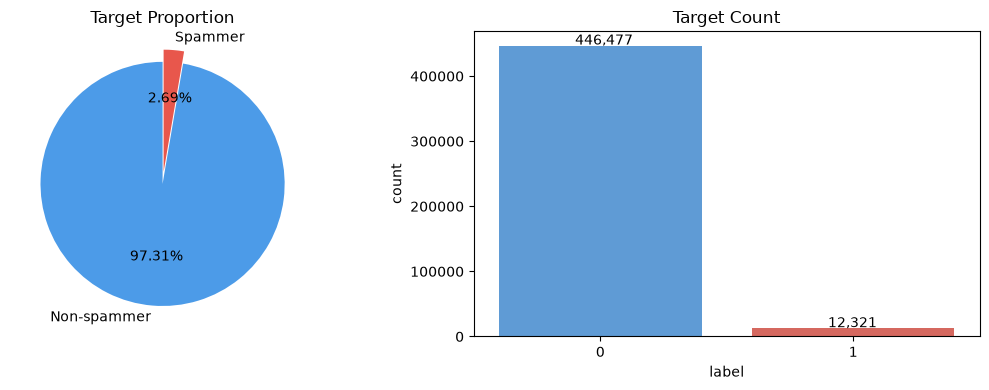

In [19]:
# ---- Target distribution (pie + bar) ----
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
counts = df_clean["label"].value_counts()
ax[0].pie(counts, labels=["Non-spammer", "Spammer"], autopct="%.2f%%",
          colors=["#4C9BE8", "#E8574C"], startangle=90, explode=(0, 0.1))
ax[0].set_title("Target Proportion")
sns.countplot(x="label", data=df_clean, palette=["#4C9BE8", "#E8574C"], ax=ax[1])
ax[1].set_title("Target Count")
for p in ax[1].patches:
    ax[1].annotate(f"{int(p.get_height()):,}", (p.get_x()+0.3, p.get_height()+2000))
plt.tight_layout(); plt.show()

### 3.2 Binary features versus the target

- **`X11 = 1`**: about 48% of these users are spammers (rare but very strong).
- **`X12 = 1`**: about 6.3%, roughly twice the base rate.
- **Protective flags**: `X49 = 1` (about 0.25%), `X20 = 1` (about 1%), `X50 = 1` (about 1.5%), `X45 = 1` (about 0.7%).

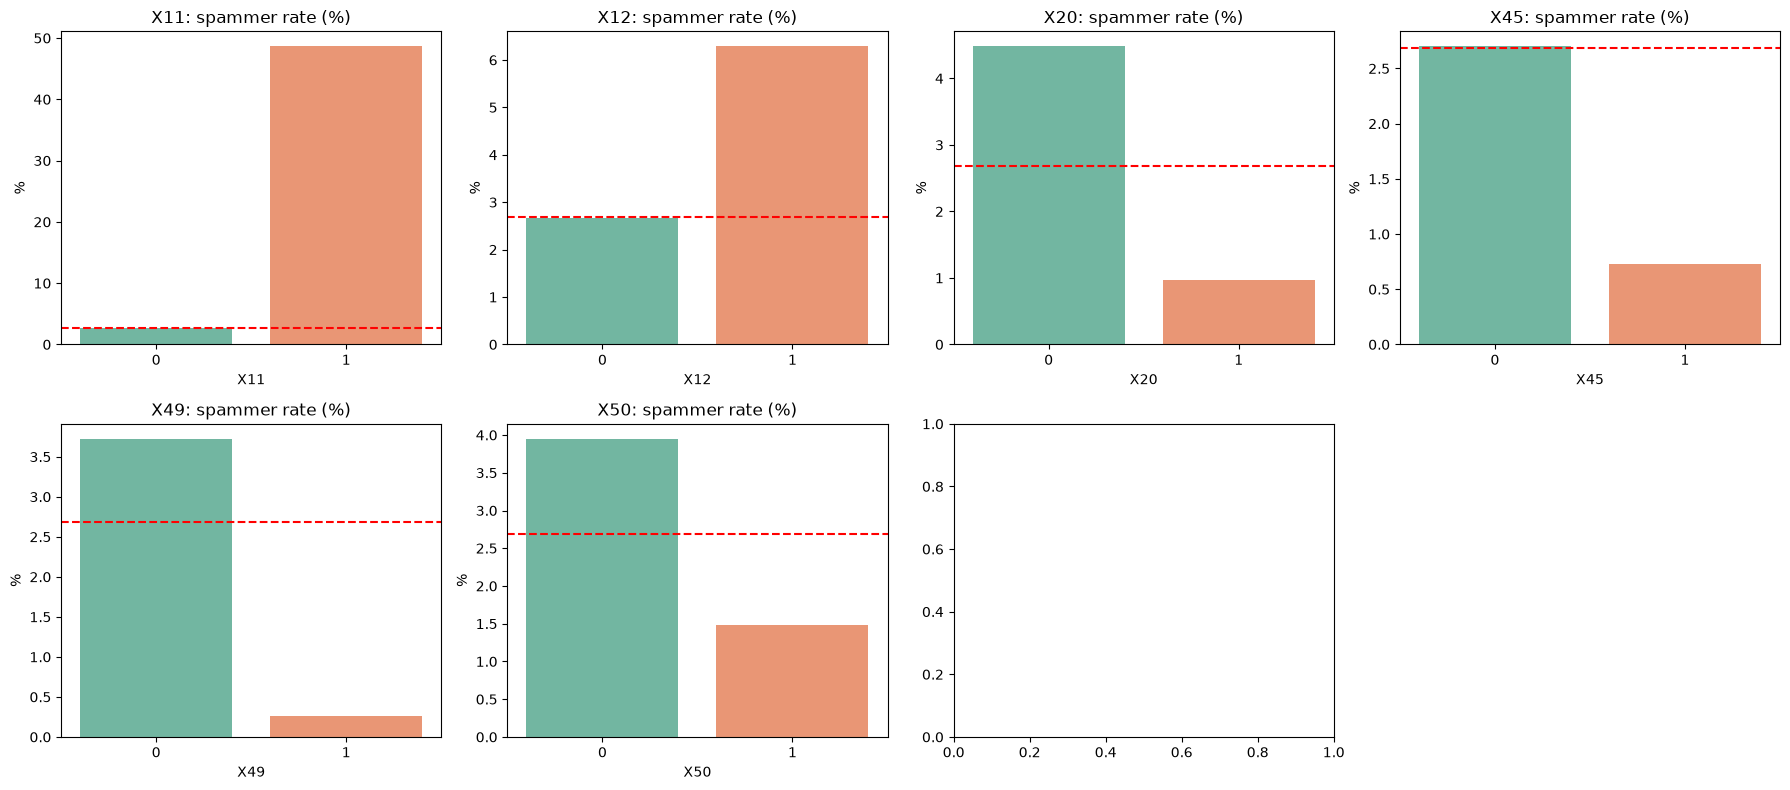

In [20]:
# ---- Spammer rate for each binary column ----
binary_cols = [c for c in ['X11','X12','X20','X45','X49','X50'] if c in df_clean.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), binary_cols):
    rate = df_clean.groupby(col)["label"].mean() * 100
    sns.barplot(x=rate.index, y=rate.values, palette="Set2", ax=ax)
    ax.axhline(overall_rate*100, color="red", ls="--", label="overall")
    ax.set_title(f"{col}: spammer rate (%)")
    ax.set_ylabel("%")
for ax in axes.ravel()[len(binary_cols):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

### 3.3 Low-cardinality features versus the target

`X15` and `X13` are counts whose spam rate rises with the count; `X4`, `X5`, `X6` and `X7` behave like **category codes** (irregular jumps across values). `X34`/`X35` look almost identical and `X23` is nearly flat (weak).

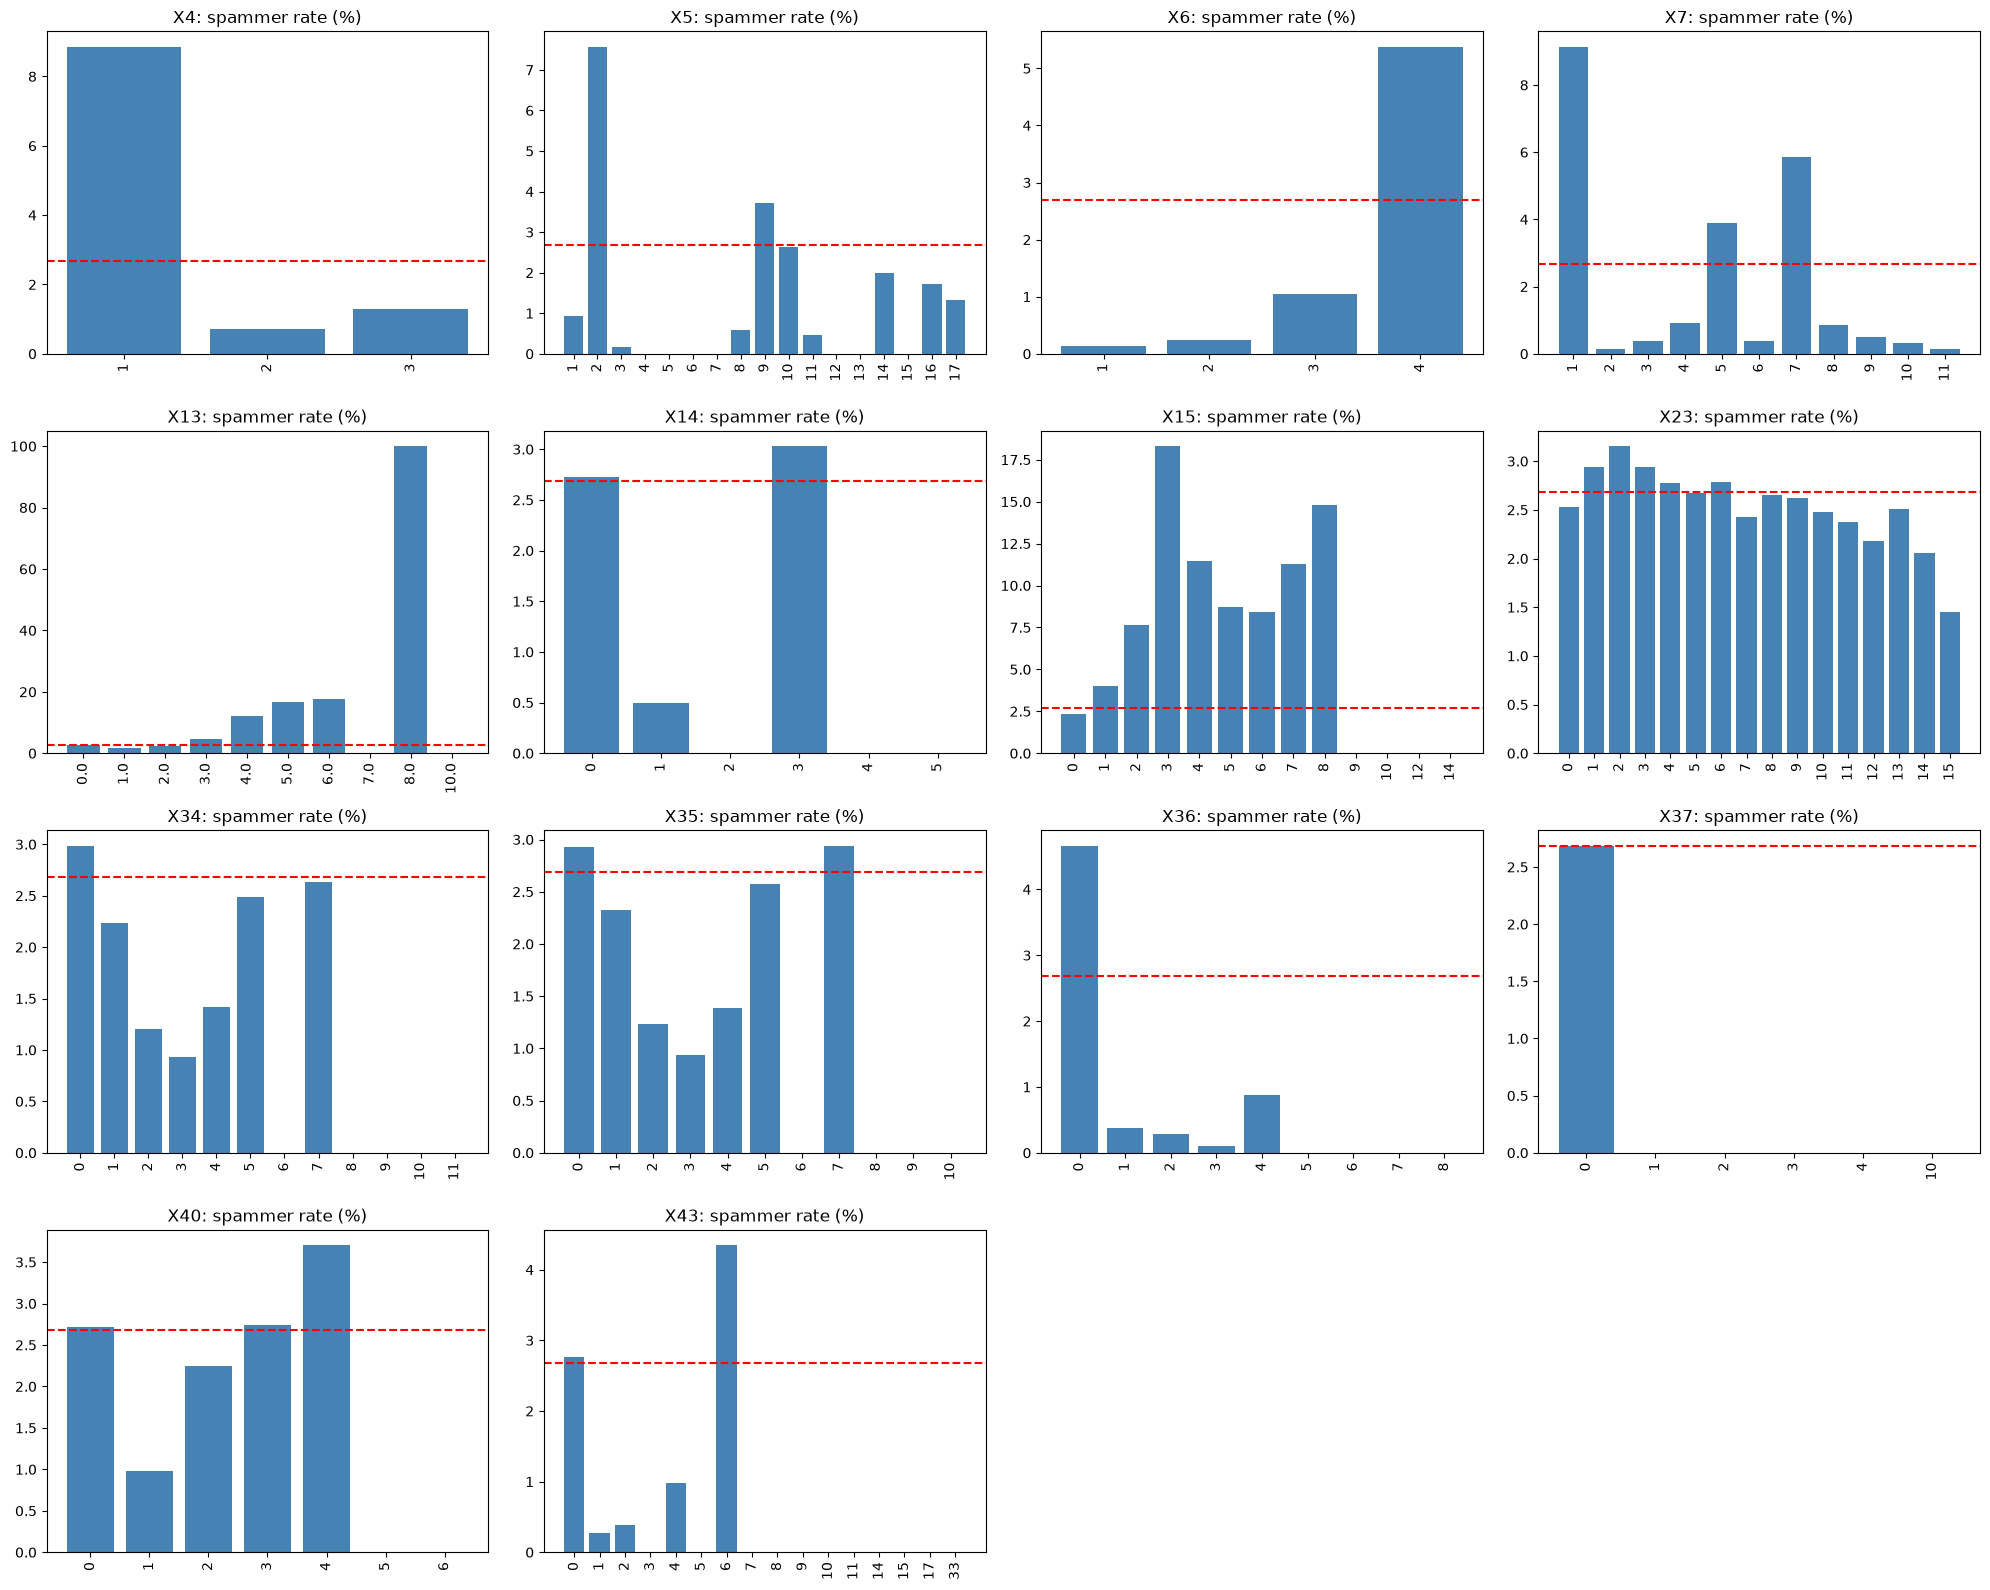

In [21]:
# ---- Spammer rate by category for X4, X5, X6, X7, etc. ----
low_card = ['X4','X5','X6','X7','X13','X14','X15','X23','X34','X35','X36','X37','X40','X43']

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for ax, col in zip(axes.ravel(), low_card):
    rate = df_clean.groupby(col)["label"].mean() * 100
    ax.bar(rate.index.astype(str), rate.values, color="steelblue")
    ax.axhline(overall_rate*100, color="red", ls="--")
    ax.set_title(f"{col}: spammer rate (%)")
    ax.tick_params(axis="x", rotation=90)
for ax in axes.ravel()[len(low_card):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

### 3.4 Correlation with the label

Linear correlations are weak (largest: `X19` at +0.26, `X4` at -0.16) even though the plots show strong non-linear patterns. This is early evidence that **tree-based models should beat linear ones**.

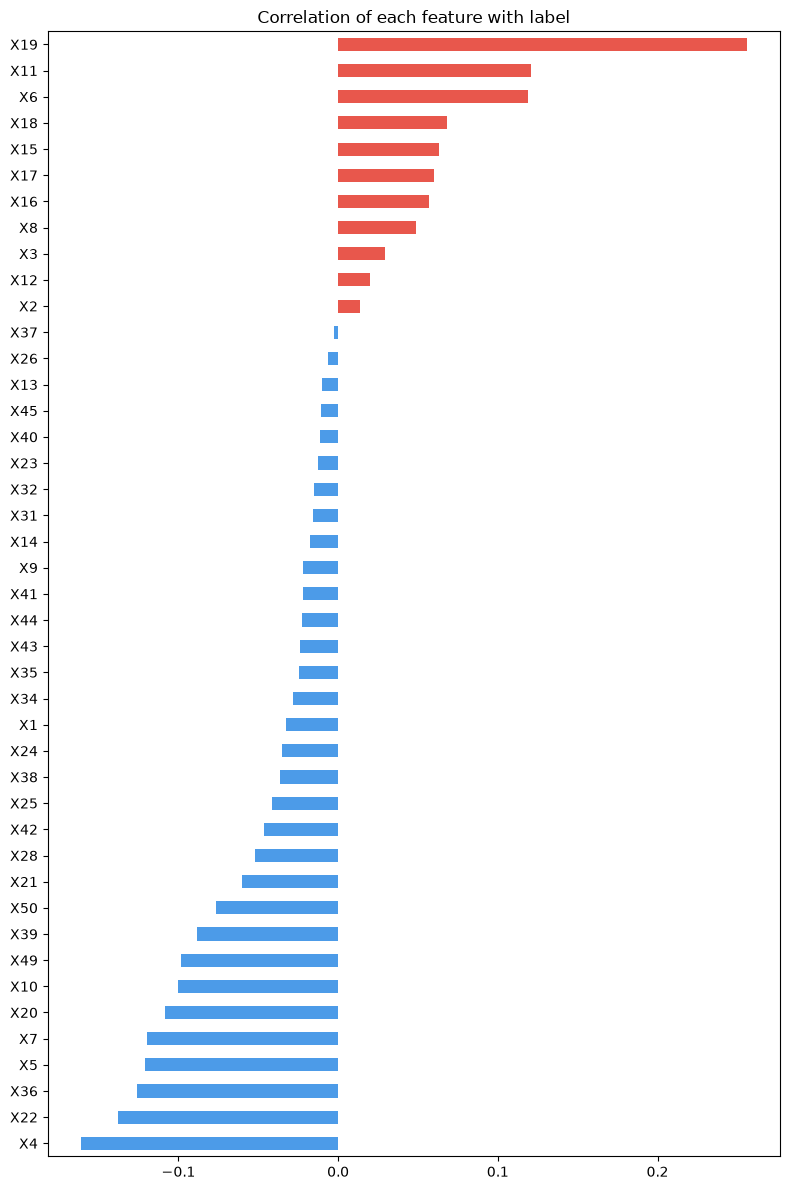

Top 10 positive:
 X12    0.019983
X3     0.029224
X8     0.048605
X16    0.057109
X17    0.059880
X15    0.062969
X18    0.068317
X6     0.118793
X11    0.120644
X19    0.255836
Name: label, dtype: float64

Top 10 negative:
 X4    -0.160983
X22   -0.137752
X36   -0.125662
X5    -0.120901
X7    -0.119792
X20   -0.108509
X10   -0.100047
X49   -0.098286
X39   -0.088430
X50   -0.076360
Name: label, dtype: float64


In [22]:
# ---- Which features correlate most with the label? ----
feats = [c for c in df_clean.columns if c not in ["user_id"]]
corr_target = df_clean[feats].corr()["label"].drop("label").sort_values()

plt.figure(figsize=(8, 12))
corr_target.plot(kind="barh", color=np.where(corr_target > 0, "#E8574C", "#4C9BE8"))
plt.title("Correlation of each feature with label")
plt.tight_layout(); plt.show()

print("Top 10 positive:\n", corr_target.tail(10))
print("\nTop 10 negative:\n", corr_target.head(10))

### 3.5 Rates with row counts

**Why:** a high spam rate only matters if it rests on enough users. For example, `X13 = 8` shows 100% but contains only 2 users, so it is noise. `X15` rises from 2.3% at 0 to 18.3% at 3 (803 users). Big codes carry the signal: `X4 = 1` (91k users, 8.9%), `X7 = 1` (84k, 9.1%), `X5 = 2` (92k, 7.6%).

In [23]:
# ---- Spammer rate + row count per category ----
def rate_table(col, min_rows=0):
    t = df_clean.groupby(col)["label"].agg(rows="count", spammers="sum", rate="mean")
    t["rate"] = t["rate"] * 100
    t["lift"] = t["rate"] / (overall_rate * 100)
    return t[t.rows >= min_rows]

for col in ["X13", "X15", "X7", "X5", "X4"]:
    print(f"\n=== {col} ===")
    display(rate_table(col))


=== X13 ===


,rows,spammers,rate,lift
X13,,,,
0.0,421784,11612,2.753068,1.025162
1.0,34326,629,1.832430,0.682343
2.0,2432,58,2.384868,0.888055
3.0,169,8,4.733728,1.762702
4.0,41,5,12.195122,4.541107
5.0,24,4,16.666667,6.206179
6.0,17,3,17.647059,6.571249
7.0,2,0,0.000000,0.000000
8.0,2,2,100.000000,37.237075



=== X15 ===


,rows,spammers,rate,lift
X15,,,,
0,388934,9082,2.335101,0.869523
1,60668,2427,4.000462,1.489655
2,7531,576,7.648387,2.848035
3,803,147,18.306351,6.816750
4,427,49,11.475410,4.273107
5,229,20,8.733624,3.252146
6,107,9,8.411215,3.132090
7,62,7,11.290323,4.204186
8,27,4,14.814815,5.516604



=== X7 ===


,rows,spammers,rate,lift
X7,,,,
1,84209,7697,9.140353,3.403600
2,42366,66,0.155785,0.058010
3,65562,246,0.375217,0.139720
4,28160,259,0.919744,0.342486
5,76309,2976,3.899933,1.452221
6,259,1,0.386100,0.143772
7,2748,161,5.858806,2.181648
8,89977,767,0.852440,0.317424
9,1605,8,0.498442,0.185605



=== X5 ===


,rows,spammers,rate,lift
X5,,,,
1,106,1,0.943396,0.351293
2,91526,6930,7.571619,2.819449
3,3057,5,0.163559,0.060905
4,37,0,0.000000,0.000000
5,1,0,0.000000,0.000000
6,19,0,0.000000,0.000000
7,2,0,0.000000,0.000000
8,47253,276,0.584090,0.217498
9,41356,1541,3.726182,1.387521



=== X4 ===


,rows,spammers,rate,lift
X4,,,,
1,91474,8103,8.858255,3.298555
2,88738,644,0.725732,0.270241
3,278586,3574,1.282907,0.477717


### 3.6 Are `X1` to `X10` numbers or codes?

**Why:** treating a code as a quantity misleads linear, SVM and KNN models.
**What we found:** `X2`, `X3`, `X8` show a single risky band instead of a trend, so they are **codes**. `X1` and `X10` have tens of thousands of unique values; `X1` is not an index (correlation with `user_id` is 0.014), and **47.5% of users have `X10 = 1`** with a 4.5% spam rate against 1.0% for the rest, so a flag `X10_is_1` is added in Section 6.

,n_unique,min,max,pct_top_value
X1,23696,1,24234,7.717122
X2,222,1,222,36.737736
X3,94,1,94,47.869433
X4,3,1,3,60.720840
X5,17,1,17,27.125663
X6,4,1,4,46.475573
X7,11,1,11,19.611463
X8,29,1,29,40.648826
X9,38,1,38,67.197329
X10,47380,1,49637,47.477321


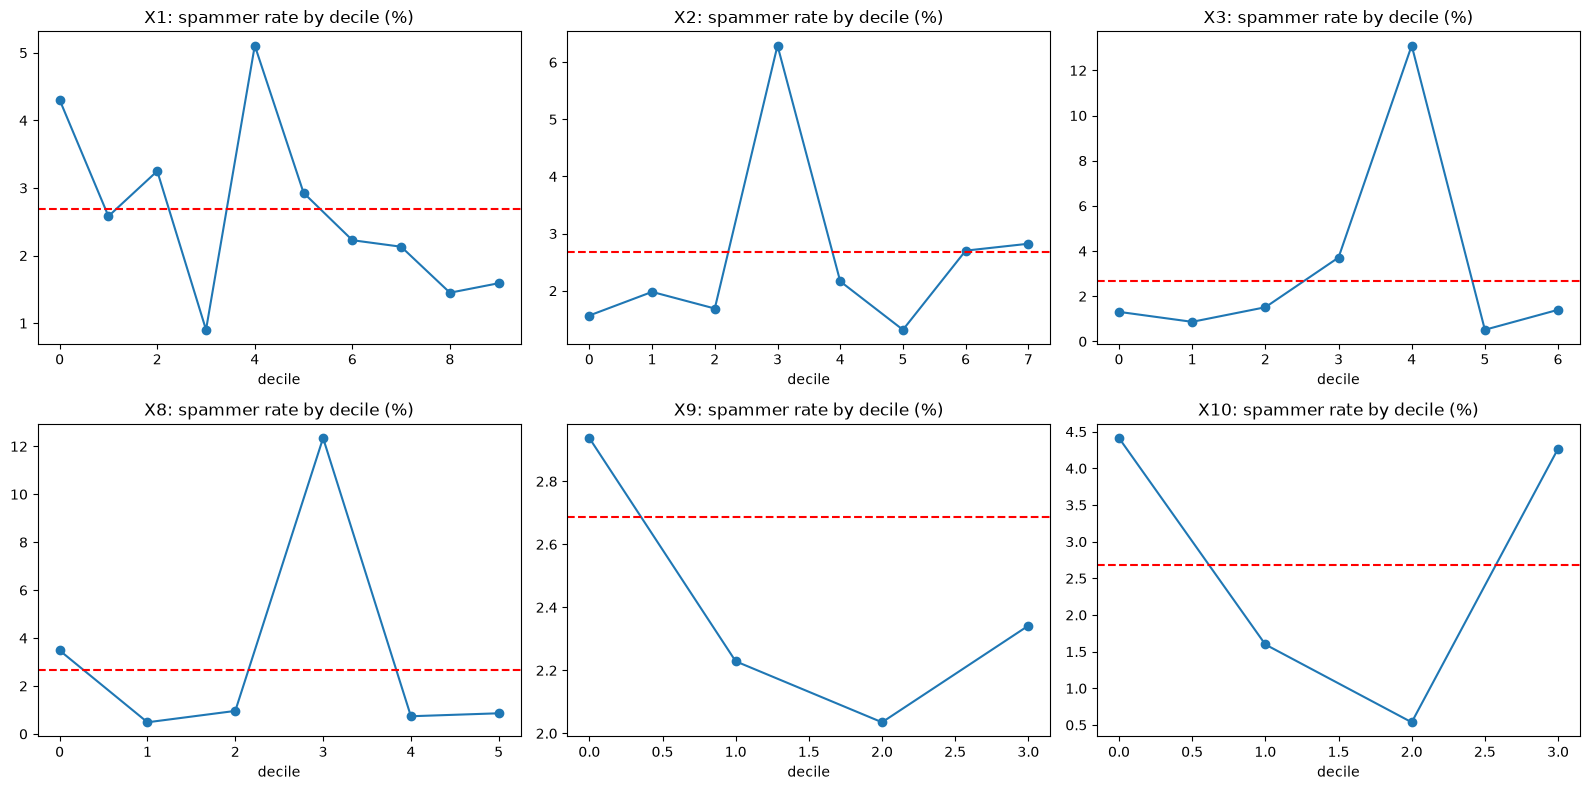

In [24]:
# ---- Cardinality and behaviour of X1-X10 ----
cols = [f"X{i}" for i in range(1, 11)]
summary = pd.DataFrame({
    "n_unique": df_clean[cols].nunique(),
    "min": df_clean[cols].min(),
    "max": df_clean[cols].max(),
    "pct_top_value": [df_clean[c].value_counts(normalize=True).iloc[0]*100 for c in cols],
})
display(summary)

# Spammer rate across quantile buckets: monotonic pattern = numeric, jumpy = code
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), ["X1","X2","X3","X8","X9","X10"]):
    b = pd.qcut(df_clean[col], q=10, duplicates="drop")
    r = df_clean.groupby(b)["label"].mean() * 100
    ax.plot(range(len(r)), r.values, marker="o")
    ax.axhline(overall_rate*100, color="red", ls="--")
    ax.set_title(f"{col}: spammer rate by decile (%)")
    ax.set_xlabel("decile")
plt.tight_layout(); plt.show()

In [26]:
# ---- Is X1 just an index? ----
print("Corr X1 vs user_id :", df_clean["X1"].corr(df_clean["user_id"]))
print("Spearman X1 vs user_id:", df_clean["X1"].corr(df_clean["user_id"], method="spearman"))
print("Corr X1 vs label   :", df_clean["X1"].corr(df_clean["label"]))
print("X10 == 1 share     :", (df_clean["X10"] == 1).mean())
print(df_clean.groupby(df_clean["X10"] == 1)["label"].mean() * 100)

Corr X1 vs user_id : 0.013957121793624386
Spearman X1 vs user_id: 0.014427733614789424
Corr X1 vs label   : -0.032692903701003216
X10 == 1 share     : 0.474773211740243
X10
False    1.033311
True     4.513256
Name: label, dtype: float64


### 3.7 Redundancy between features

`X34`/`X35` (correlation 0.97, equal in 98.5% of rows) are near-duplicates, so `X35` is dropped in Section 4. Other correlated pairs (`X41`/`X44` 0.93, `X10`/`X20` 0.86, `X16`/`X18` 0.84) each carry label signal and are kept; tree models are insensitive to redundancy.

In [25]:
# ---- Is X34 the same as X35? ----
print("Correlation X34 vs X35:", df_clean["X34"].corr(df_clean["X35"]))
print("Rows where X34 == X35 :", (df_clean["X34"] == df_clean["X35"]).mean())

# ---- Highly correlated pairs across all features ----
feats = [c for c in df_clean.columns if c not in ["label", "user_id"]]
cm = df_clean[feats].corr().abs()
upper = cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool))
pairs = upper.stack().sort_values(ascending=False)
display(pairs[pairs > 0.8].to_frame("abs_corr"))

Correlation X34 vs X35: 0.971655500795406
Rows where X34 == X35 : 0.9851655848543368


,,abs_corr
X34,X35,0.971656
X41,X44,0.931156
X10,X20,0.861655
X16,X18,0.844022


In [27]:
# ----  Which column of each pair is more related to the label? ----
pairs = [("X34","X35"), ("X41","X44"), ("X10","X20"), ("X16","X18")]
rows = []
for a, b in pairs:
    rows.append({"pair": f"{a}/{b}",
                 f"corr({a},label)": df_clean[a].corr(df_clean["label"]),
                 f"corr({b},label)": df_clean[b].corr(df_clean["label"])})
display(pd.DataFrame(rows))

,pair,"corr(X34,label)","corr(X35,label)","corr(X41,label)","corr(X44,label)","corr(X10,label)","corr(X20,label)","corr(X16,label)","corr(X18,label)"
0,X34/X35,-0.02818,-0.024651,NaN,NaN,NaN,NaN,NaN,NaN
1,X41/X44,NaN,NaN,-0.022142,-0.022635,NaN,NaN,NaN,NaN
2,X10/X20,NaN,NaN,NaN,NaN,-0.100047,-0.108509,NaN,NaN
3,X16/X18,NaN,NaN,NaN,NaN,NaN,NaN,0.057109,0.068317


### 3.8 Risky codes and the segment they define

`X4 = 1`, `X7 = 1`, `X8 = 21`, `X3 = 37` and `X5 = 2` are strongly correlated (`X4`/`X7` at 0.94): they mark largely the same user segment. Users with all five flags number **34,056 with a 17.6% spam rate** (6.5 times the base rate). `X2 = 147` is a separate group (22.7% spam rate, correlation about 0.1 with the others).

In [28]:
# ---- Which exact codes are risky, and how many users are in them? ----
for col in ["X2", "X3", "X8"]:
    t = df_clean.groupby(col)["label"].agg(rows="count", spammers="sum", rate="mean")
    t["rate"] = (t["rate"] * 100).round(2)
    print(f"\n=== {col}: top 8 codes by spammer count ===")
    print(t.sort_values("spammers", ascending=False).head(8).to_string())


=== X2: top 8 codes by spammer count ===
       rows  spammers   rate
X2                          
213  168552      4554   2.70
147   14275      3239  22.69
212   37030       548   1.48
40    20678       535   2.59
95    22678       427   1.88
72     9308       352   3.78
142    6893       295   4.28
166    1847       264  14.29

=== X3: top 8 codes by spammer count ===
      rows  spammers   rate
X3                         
37   50097      6562  13.10
13  219624      2866   1.30
36   41352      1541   3.73
33   21894       480   2.19
14   21692       188   0.87
58    6519       134   2.06
28   18781        98   0.52
51   23992        98   0.41

=== X8: top 8 codes by spammer count ===
      rows  spammers   rate
X8                         
21   58001      7162  12.35
9    76309      2976   3.90
15  186496      1018   0.55
22   59493       439   0.74
7     4707       237   5.04
16    3334       115   3.45
25    1390        79   5.68
6     1204        76   6.31


In [29]:
# ---- Overlap between the risky codes ----
seg = pd.DataFrame({
    "X4=1":  df_clean["X4"] == 1,
    "X7=1":  df_clean["X7"] == 1,
    "X8=21": df_clean["X8"] == 21,
    "X5=2":  df_clean["X5"] == 2,
    "X3=37": df_clean["X3"] == 37,
    "X2=147": df_clean["X2"] == 147,
})
print("Share of users in each flag:\n", seg.mean().round(3), "\n")
display(seg.astype(int).corr().round(2))

# Spammer rate when ALL of the first five flags are true
all_flags = seg[["X4=1","X7=1","X8=21","X5=2","X3=37"]].all(axis=1)
print("Users with all 5 flags:", all_flags.sum(),
      "| spammer rate:", f"{df_clean.loc[all_flags,'label'].mean():.2%}")

Share of users in each flag:
 X4=1      0.199
X7=1      0.184
X8=21     0.126
X5=2      0.199
X3=37     0.109
X2=147    0.031
dtype: float64 



,X4=1,X7=1,X8=21,X5=2,X3=37,X2=147
X4=1,1.00,0.94,0.76,0.43,0.70,0.09
X7=1,0.94,1.00,0.80,0.43,0.68,0.10
X8=21,0.76,0.80,1.00,0.37,0.58,0.11
X5=2,0.43,0.43,0.37,1.00,0.70,0.12
X3=37,0.70,0.68,0.58,0.70,1.00,0.13
X2=147,0.09,0.10,0.11,0.12,0.13,1.00


Users with all 5 flags: 34056 | spammer rate: 17.58%


## 4. Distributions, skewness and transformation

**Why:** strongly skewed variables distort linear models, SVM and KNN and let a few extreme values dominate.
**How:** skewness, kurtosis and zero share for the 29 numeric (count) columns, histograms on a log axis, then `log1p` (log of 1 + x, safe at zero). `X37` and `X26` (over 99% zeros) are left unchanged.
**What we found:** **23 of 29 columns have |skew| above 1**, almost all zero-heavy counts. After `log1p`, columns with 60 to 80% zeros are fixed (for example `X25`: 91.2 to 1.8; `X21`: 4.7 to 0.6). Columns with over 90% zeros (`X19`, `X44`, `X41`) improve but stay skewed because a spike at zero cannot be removed by any transformation.
**Note:** tree models split on thresholds and are unaffected by `log1p`, so two versions of the data are built in Section 6.

In [30]:
# ---- Drop X35 and define column groups ----
df_clean = df_clean.drop(columns=["X35"])

code_cols   = ["X2","X3","X4","X5","X6","X7","X8"]          # category codes
binary_cols = ["X11","X12","X20","X45","X49","X50"]          # 0/1 flags
cont_cols   = [c for c in df_clean.columns
               if c not in ["label","user_id"] + code_cols + binary_cols]

print("Count/numeric columns:", len(cont_cols), cont_cols)

Count/numeric columns: 29 ['X1', 'X9', 'X10', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X28', 'X31', 'X32', 'X34', 'X36', 'X37', 'X38', 'X39', 'X40', 'X41', 'X42', 'X43', 'X44']


In [31]:
# ---- Skewness, kurtosis, zeros ----
stats = pd.DataFrame({
    "skew":      df_clean[cont_cols].skew(),
    "kurtosis":  df_clean[cont_cols].kurt(),
    "zeros_pct": (df_clean[cont_cols] == 0).mean() * 100,
    "median":    df_clean[cont_cols].median(),
    "max":       df_clean[cont_cols].max(),
}).sort_values("skew", ascending=False)

display(stats.round(2))
print("\nColumns with |skew| > 1:", (stats["skew"].abs() > 1).sum(), "of", len(stats))

,skew,kurtosis,zeros_pct,median,max
X37,118.70,26296.57,99.96,0.0,10.0
X25,91.24,17051.22,69.61,0.0,688.0
X26,49.16,3763.40,99.35,0.0,63.0
X32,42.16,6487.08,67.78,0.0,333.0
X19,30.41,1252.84,93.63,0.0,213.0
X31,29.42,5488.84,65.87,0.0,201.0
X44,24.14,1884.13,94.71,0.0,56.0
X41,20.61,1508.00,95.35,0.0,56.0
X43,15.35,888.82,96.57,0.0,33.0
X38,13.96,798.01,92.44,0.0,38.0



Columns with |skew| > 1: 23 of 29


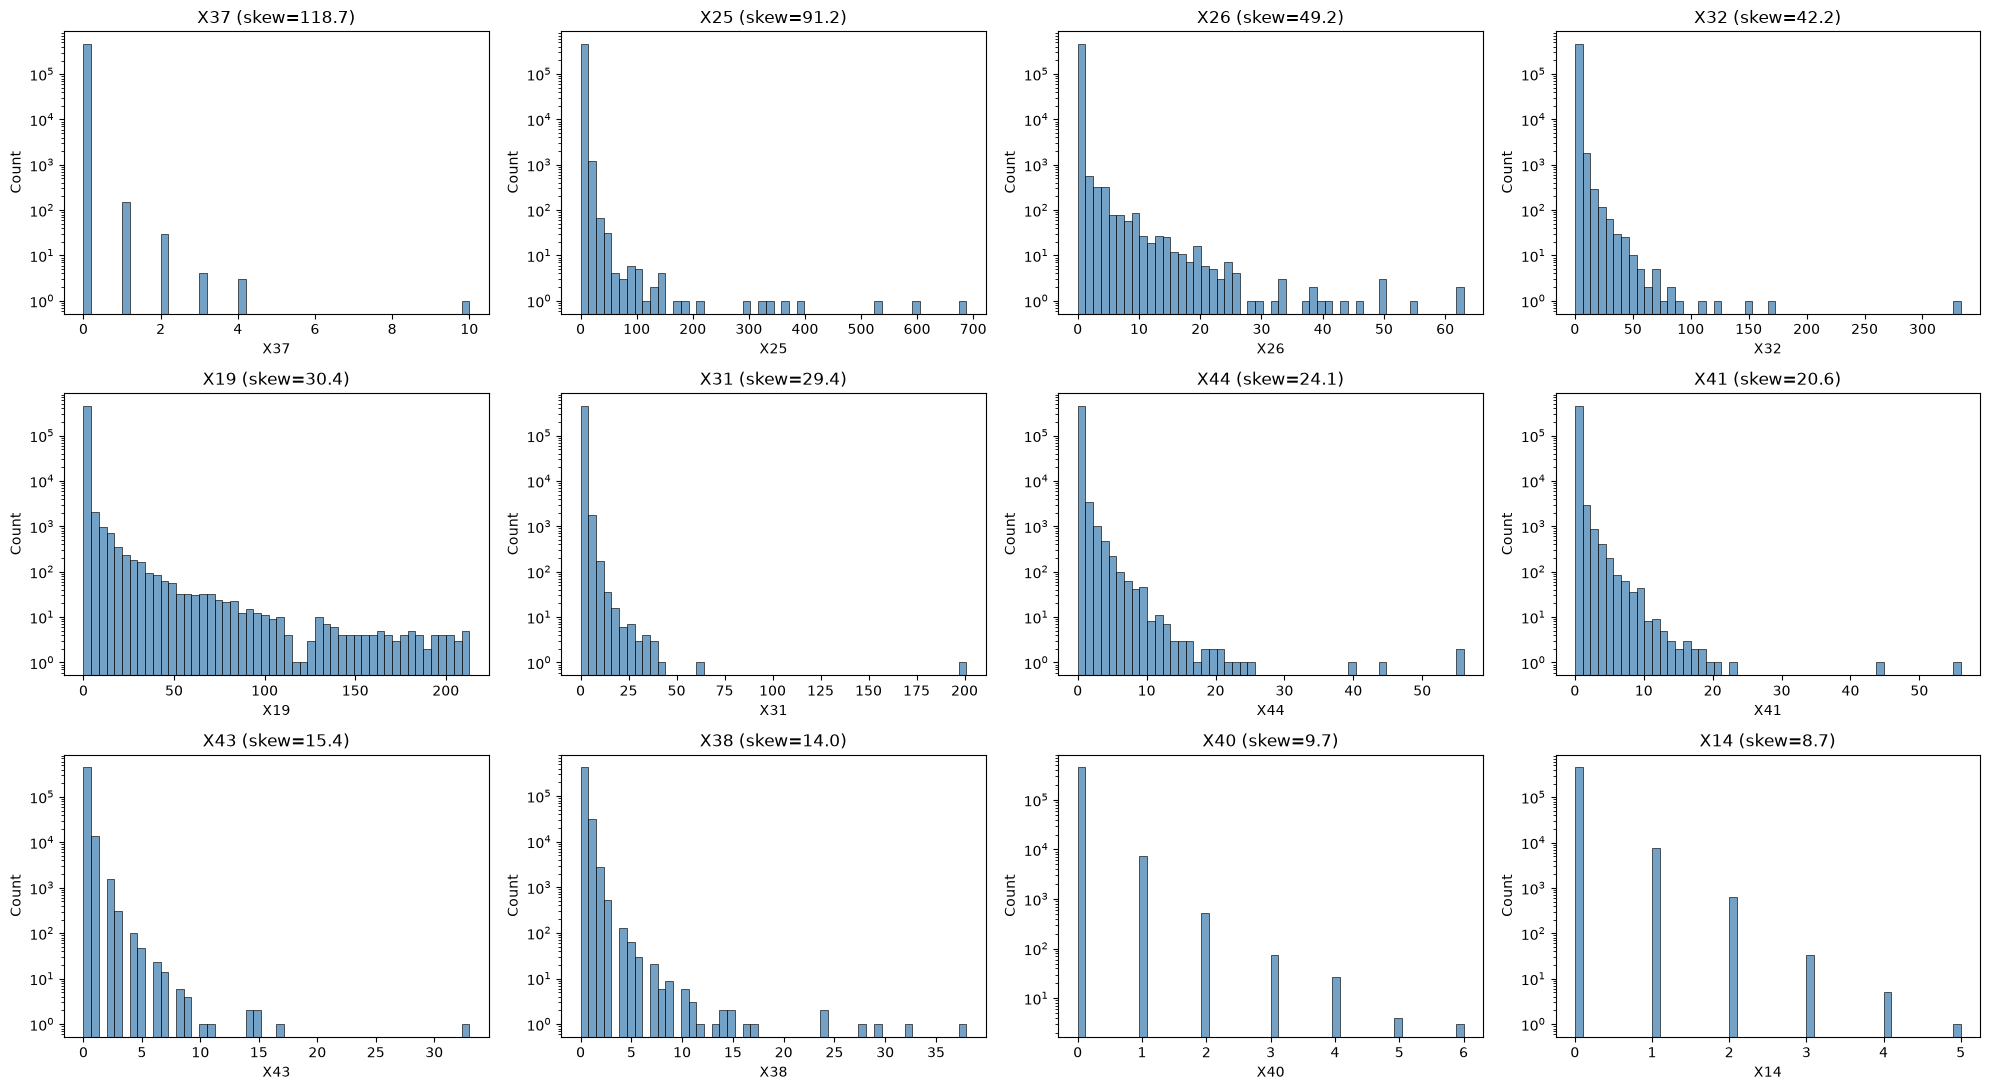

In [32]:
# ----Histograms of the 12 most skewed columns ----
top = stats.index[:12]
fig, axes = plt.subplots(3, 4, figsize=(20, 11))
for ax, col in zip(axes.ravel(), top):
    sns.histplot(df_clean[col], bins=50, ax=ax, color="steelblue")
    ax.set_yscale("log")                 # log y-axis so the tail is visible
    ax.set_title(f"{col} (skew={stats.loc[col,'skew']:.1f})")
plt.tight_layout(); plt.show()

In [33]:
# ---- log1p transform on skewed columns ----
skewed = stats[stats["skew"].abs() > 1].index.tolist()
skewed = [c for c in skewed if c not in ["X37", "X26"]]   # near-constant flags: leave as is

df_log = df_clean.copy()                                   # keep df_clean as the raw version
df_log[skewed] = np.log1p(df_log[skewed])

cmp = pd.DataFrame({
    "skew_before": df_clean[skewed].skew(),
    "skew_after":  df_log[skewed].skew(),
    "zeros_pct":   (df_clean[skewed] == 0).mean() * 100,
}).sort_values("skew_before", ascending=False)
display(cmp.round(2))

,skew_before,skew_after,zeros_pct
X25,91.24,1.81,69.61
X32,42.16,1.63,67.78
X19,30.41,6.69,93.63
X31,29.42,1.25,65.87
X44,24.14,5.16,94.71
X41,20.61,5.51,95.35
X43,15.35,5.93,96.57
X38,13.96,3.71,92.44
X40,9.75,7.88,98.24
X14,8.69,7.71,98.22


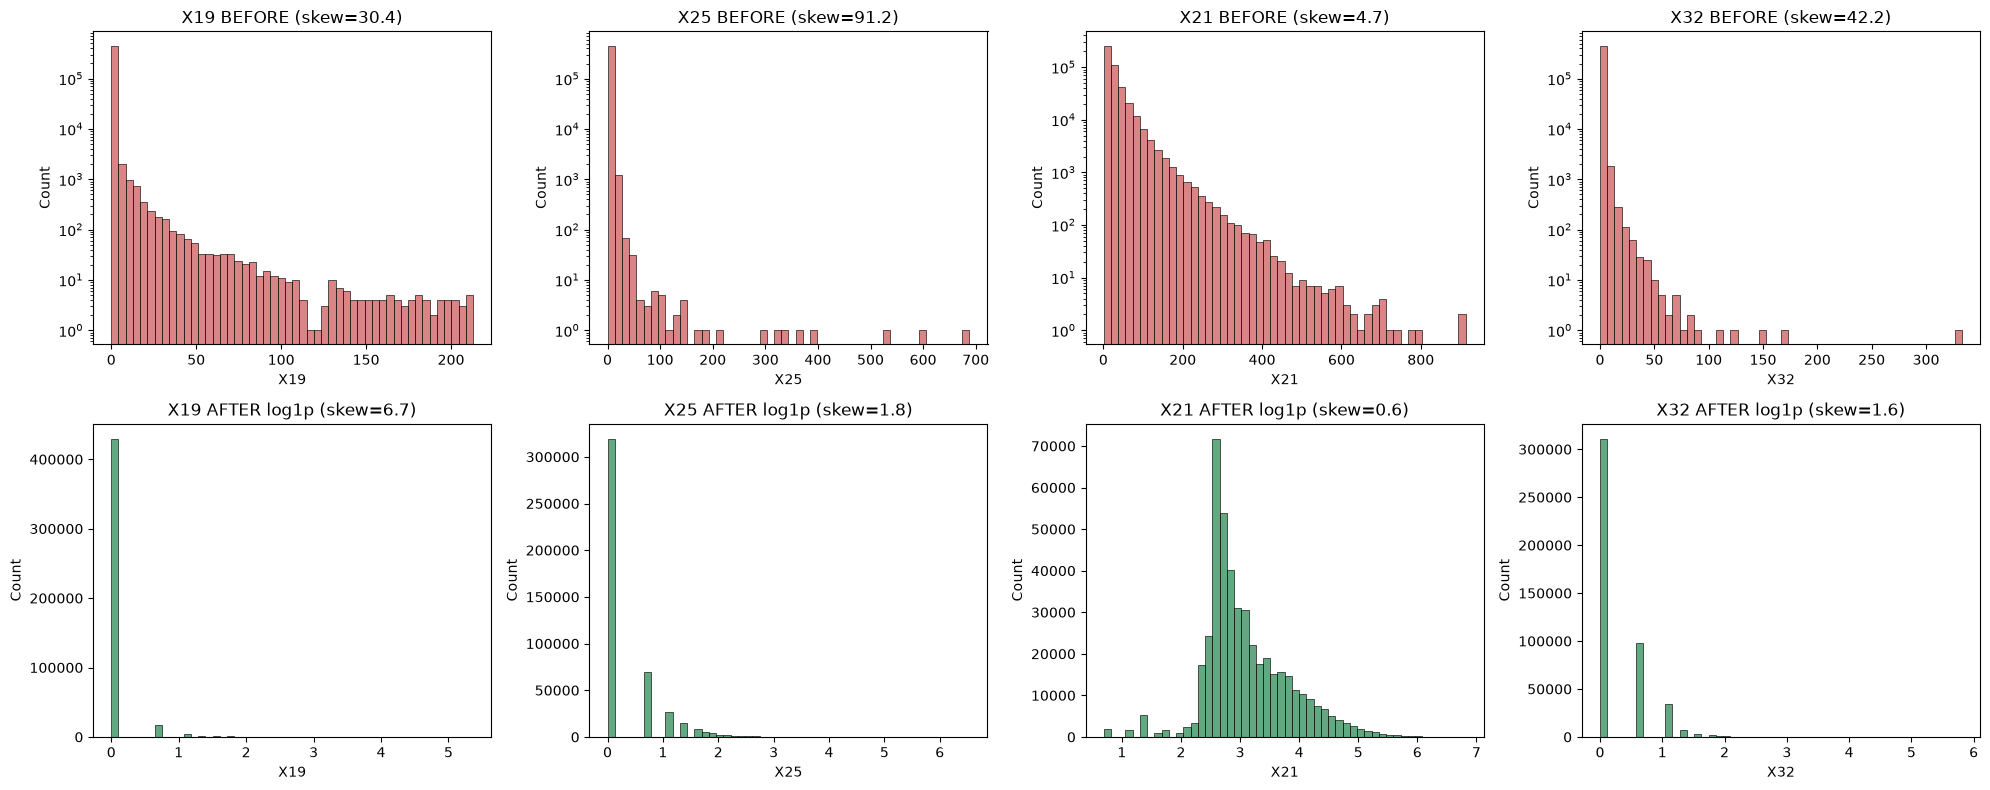

In [34]:
# ---- Before vs after for 4 columns ----
show = ["X19", "X25", "X21", "X32"]
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, col in enumerate(show):
    sns.histplot(df_clean[col], bins=50, ax=axes[0, i], color="indianred")
    axes[0, i].set_yscale("log")
    axes[0, i].set_title(f"{col} BEFORE (skew={df_clean[col].skew():.1f})")
    sns.histplot(df_log[col], bins=50, ax=axes[1, i], color="seagreen")
    axes[1, i].set_title(f"{col} AFTER log1p (skew={df_log[col].skew():.1f})")
plt.tight_layout(); plt.show()

## 5. Outliers and feature scaling

**Why:** extreme values can distort distance- and weight-based models, **but in spam detection an extreme value is often what a spammer looks like**.
**How:** because 70 to 99% of many columns are zero, the IQR rule would flag every non-zero value, so outliers are defined by percentile (above the 99th), and the spam rate among them is checked before deciding.
**What we found:** the extremes are mostly **signal**: above p99, `X19` has a 70% spam rate, `X15` 14% and `X10` 10%. For `X21`, `X22`, `X25`, `X24` extreme values point to genuine users (0.2 to 0.5%).
**Decision:** no rows are deleted. Tree models get raw values. For Logistic Regression, SVM and KNN the columns are capped at the 99.9th percentile (fitted on the training split only), log-transformed and standardised. Capping at p99.9 (`X19` = 46) rather than p99 (`X19` = 6) preserves the range where the signal is strongest.

In [35]:
# ---- Outliers by percentile, plus spammer rate among them ----
num_cols = [c for c in cont_cols if c in df_clean.columns and c not in ["X37", "X26"]]

rows = []
for c in num_cols:
    p99  = df_clean[c].quantile(0.99)
    p999 = df_clean[c].quantile(0.999)
    hi = df_clean[df_clean[c] > p99]
    rows.append({
        "col": c,
        "p99": p99,
        "p99.9": p999,
        "max": df_clean[c].max(),
        "rows_above_p99": len(hi),
        "spam_rate_above_p99_%": hi["label"].mean() * 100 if len(hi) else np.nan,
    })
out = pd.DataFrame(rows).sort_values("spam_rate_above_p99_%", ascending=False)
display(out.round(2))
print("Overall spammer rate: %.2f%%" % (overall_rate * 100))

,col,p99,p99.9,max,rows_above_p99,spam_rate_above_p99_%
9,X19,6.0,46.0,213.0,4133,70.12
5,X15,2.0,4.0,14.0,1665,14.17
2,X10,49593.0,49623.0,49637.0,3864,10.02
8,X18,15.0,17.0,25.0,1995,6.22
1,X9,36.0,37.0,38.0,852,5.52
6,X16,22.0,28.0,48.0,4202,5.19
7,X17,7.0,11.0,26.0,3459,4.19
16,X31,3.0,7.0,201.0,4352,3.47
3,X13,1.0,2.0,10.0,2688,2.98
22,X40,1.0,2.0,6.0,642,2.34


Overall spammer rate: 2.69%


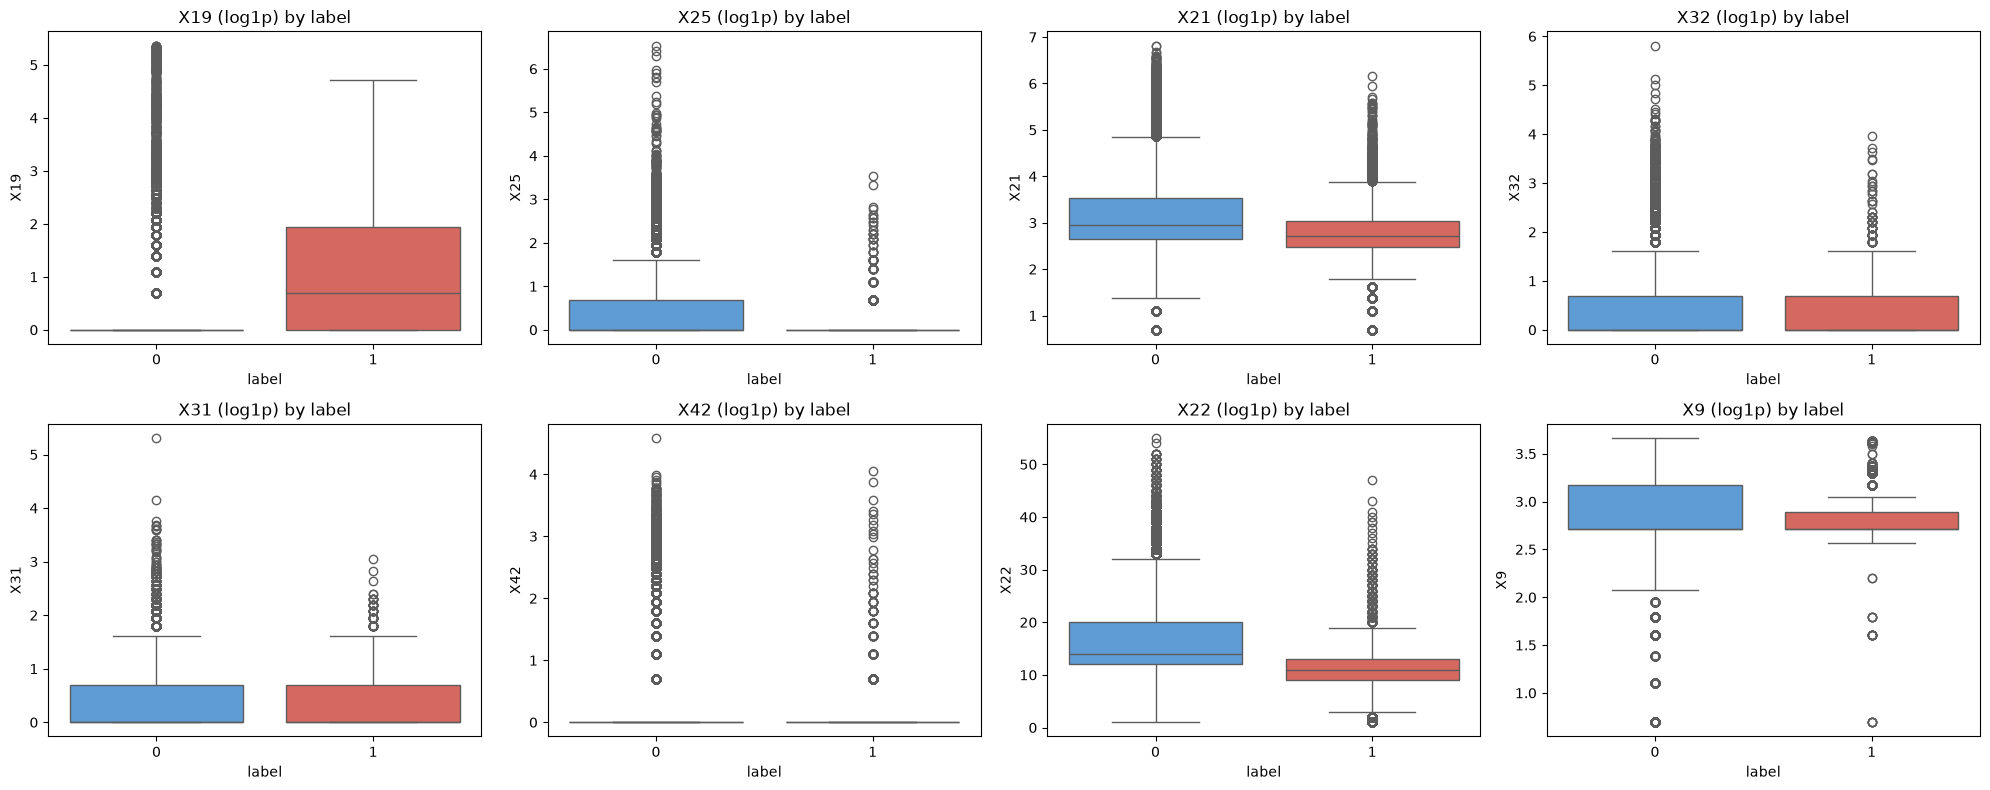

In [36]:
# ----  Boxplots on the log-transformed version ----
cols = ["X19", "X25", "X21", "X32", "X31", "X42", "X22", "X9"]
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, c in zip(axes.ravel(), cols):
    sns.boxplot(x="label", y=c, data=df_log, ax=ax, palette=["#4C9BE8", "#E8574C"], showfliers=True)
    ax.set_title(f"{c} (log1p) by label")
plt.tight_layout(); plt.show()

### X19: dose-response check

The spam rate climbs steadily with `X19`, from 1.2% at zero to **83% at 26 to 50**. Only 6.4% of users have `X19 > 0`, yet they contain about 59% of all spammers. The very top group (51 and above, 407 users) drops to 44%, which is why trees (which can model rise-then-fall) suit this data better than linear models.

In [37]:
# ----How does X19's spammer rate change with its value? ----
t = df_clean.groupby(pd.cut(df_clean["X19"], [-1, 0, 1, 2, 5, 10, 25, 50, 300]))["label"] \
            .agg(rows="count", spammers="sum", rate="mean")
t["rate"] = (t["rate"] * 100).round(2)
print(t.to_string())

             rows  spammers   rate
X19                               
(-1, 0]    429573      5054   1.18
(0, 1]      17604      1499   8.52
(1, 2]       3606       953  26.43
(2, 5]       3338      1596  47.81
(5, 10]      1890      1194  63.17
(10, 25]     1757      1326  75.47
(25, 50]      623       519  83.31
(50, 300]     407       180  44.23


## 6. Encoding, feature engineering and data split

**Why:** code columns (`X2` to `X8`) are labels, not quantities, and wide codes (`X2` has 222 values) are too many for one-hot encoding. Anything that learns from the data must be fitted on the **training split only** to prevent leakage.
**How:**
1. Stratified **70/15/15** train/validation/test split (all three keep the 2.69% spam rate).
2. Dataset A (for trees): raw values plus the flag `X10_is_1`.
3. Target encoding of the code columns (smoothed spam rate, smoothing strength 50, 5-fold out-of-fold values for training rows so no row sees its own label).
4. Dataset B (for Logistic Regression, SVM, KNN, Naive Bayes): winsorise at p99.9, `log1p`, target-encoded codes, `StandardScaler`.
**What we found:** the split sizes are 321,158 / 68,820 / 68,820 with 8,625 / 1,848 / 1,848 spammers (2.686% / 2.685% / 2.685%). Both datasets have 43 columns and no missing values.

In [38]:
# ----Stratified split ----
y = df_clean["label"]
X = df_clean.drop(columns=["label", "user_id"])

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_STATE)

for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:5s}: {len(yy):>7,} rows | spammers {yy.sum():>6,} | rate {yy.mean():.3%}")

train: 321,158 rows | spammers  8,625 | rate 2.686%
val  :  68,820 rows | spammers  1,848 | rate 2.685%
test :  68,820 rows | spammers  1,848 | rate 2.685%


In [39]:
# ----Dataset A for tree models (raw values + one extra flag) ----
def add_flags(d):
    d = d.copy()
    d["X10_is_1"] = (d["X10"] == 1).astype(int)
    return d

XA_train, XA_val, XA_test = add_flags(X_train), add_flags(X_val), add_flags(X_test)
print("Dataset A (trees):", XA_train.shape)

Dataset A (trees): (321158, 43)


In [40]:
# ---- Target encoding of code columns (fit on train only) ----
# Each code is replaced by a smoothed spammer rate. Train rows use out-of-fold values,
# so a row never sees its own label (this prevents leakage and overfitting).
code_cols = ["X2", "X3", "X4", "X5", "X6", "X7", "X8"]
prior = y_train.mean()
M = 50    # smoothing: rare codes get pulled towards the overall rate

def fit_te(col, yy):
    g = yy.groupby(col).agg(["sum", "count"])
    return (g["sum"] + M * prior) / (g["count"] + M)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
te_train = pd.DataFrame(index=X_train.index, columns=code_cols, dtype=float)
te_val, te_test = pd.DataFrame(index=X_val.index), pd.DataFrame(index=X_test.index)

for c in code_cols:
    for tr_idx, ho_idx in skf.split(X_train, y_train):
        enc = fit_te(X_train.iloc[tr_idx][c], y_train.iloc[tr_idx])
        te_train.iloc[ho_idx, te_train.columns.get_loc(c)] = \
            X_train.iloc[ho_idx][c].map(enc).fillna(prior).values
    full = fit_te(X_train[c], y_train)                       # used for val and test
    te_val[c]  = X_val[c].map(full).fillna(prior)
    te_test[c] = X_test[c].map(full).fillna(prior)

te_train.columns = te_val.columns = te_test.columns = [f"{c}_te" for c in code_cols]
display(te_train.describe().T.round(4))

,count,mean,std,min,25%,50%,75%,max
X2_te,321158.0,0.0269,0.0380,0.0017,0.0116,0.0252,0.0266,0.3634
X3_te,321158.0,0.0267,0.0377,0.0016,0.0091,0.0131,0.0212,0.2969
X4_te,321158.0,0.0269,0.0308,0.0070,0.0127,0.0129,0.0130,0.0889
X5_te,321158.0,0.0269,0.0258,0.0019,0.0062,0.0171,0.0371,0.0759
X6_te,321158.0,0.0269,0.0225,0.0013,0.0103,0.0104,0.0540,0.0541
X7_te,321158.0,0.0269,0.0333,0.0013,0.0036,0.0083,0.0391,0.0920
X8_te,321158.0,0.0269,0.0390,0.0005,0.0054,0.0055,0.0387,0.1238


In [41]:
# ---- Dataset B for linear/SVM/KNN (log1p + cap + target encoding + scaling) ----
log_cols = skewed                                  # list
cap_cols = [c for c in num_cols if c in X_train.columns]
caps = X_train[cap_cols].quantile(0.999)           # learned from TRAIN only

def make_B(d, te):
    d = add_flags(d).drop(columns=code_cols)
    d[cap_cols] = d[cap_cols].clip(upper=caps, axis=1)          # winsorize at p99.9
    lc = [c for c in log_cols if c in d.columns]
    d[lc] = np.log1p(d[lc])                                      # skew fix
    return pd.concat([d, te], axis=1)

XB_train = make_B(X_train, te_train)
XB_val   = make_B(X_val,   te_val)
XB_test  = make_B(X_test,  te_test)

scaler = StandardScaler().fit(XB_train)            # fit on train only
XB_train_s = pd.DataFrame(scaler.transform(XB_train), columns=XB_train.columns, index=XB_train.index)
XB_val_s   = pd.DataFrame(scaler.transform(XB_val),   columns=XB_train.columns, index=XB_val.index)
XB_test_s  = pd.DataFrame(scaler.transform(XB_test),  columns=XB_train.columns, index=XB_test.index)

print("Dataset B (scaled):", XB_train_s.shape)
print("Any NaN?", XB_train_s.isnull().sum().sum(), XB_val_s.isnull().sum().sum())
display(XB_train_s.describe().T[["mean", "std", "min", "max"]].round(2).head(10))

Dataset B (scaled): (321158, 43)
Any NaN? 0 0


,mean,std,min,max
X1,0.0,1.0,-1.53,1.89
X9,-0.0,1.0,-7.24,2.52
X10,-0.0,1.0,-0.89,1.28
X11,-0.0,1.0,-0.04,23.35
X12,-0.0,1.0,-0.09,11.17
X13,-0.0,1.0,-0.29,5.24
X14,-0.0,1.0,-0.13,11.21
X15,-0.0,1.0,-0.41,5.33
X16,0.0,1.0,-2.81,4.14
X17,-0.0,1.0,-0.94,2.58


## 7. Model building and comparison

**Why:** a fair comparison across algorithm families shows which kind of model suits the data.
**How:**
- **Main metric: PR-AUC** (average precision), which suits imbalanced data (a random model scores about 0.027). Precision, recall and F1 are reported at the threshold that maximises F1 on the validation set.
- **Imbalance** is handled with class weights (`class_weight='balanced'` / `scale_pos_weight`).
- Trees and boosting use Dataset A; Logistic Regression, Naive Bayes, KNN and SVM use Dataset B. KNN and the SVMs train on stratified subsamples (60,000 and 40,000 rows) because they do not scale to 321,000 rows.
- Only the validation set is used for comparison. The test set stays untouched until Section 9.

### 7.1 Evaluation helper
`evaluate()` scores a model on validation, finds the best-F1 threshold, and stores PR-AUC, ROC-AUC, precision, recall, F1 and a train-set PR-AUC (to measure overfitting).

In [42]:
# ----  Evaluation helper ----
results = []                      # collects one row per model
fitted = {}                       # keeps fitted models for later steps

def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)

def evaluate(name, model, Xtr, ytr, Xva, yva, family, fit_time):
    s_val = get_scores(model, Xva)
    # train score on a 60k sample, so overfitting can be checked 
    idx = Xtr.sample(n=min(60000, len(Xtr)), random_state=RANDOM_STATE).index
    s_tr = get_scores(model, Xtr.loc[idx])

    p, r, t = precision_recall_curve(yva, s_val)
    f1s = 2 * p[:-1] * r[:-1] / (p[:-1] + r[:-1] + 1e-12)
    best = f1s.argmax()
    thr = t[best]
    pred = (s_val >= thr).astype(int)

    results.append({
        "model": name, "family": family,
        "val_PR_AUC": average_precision_score(yva, s_val),
        "train_PR_AUC": average_precision_score(ytr.loc[idx], s_tr),
        "val_ROC_AUC": roc_auc_score(yva, s_val),
        "precision": precision_score(yva, pred),
        "recall": recall_score(yva, pred),
        "F1": f1_score(yva, pred),
        "threshold": thr, "fit_sec": fit_time,
    })
    fitted[name] = model
    print(f"{name:28s} PR-AUC={results[-1]['val_PR_AUC']:.4f}  F1={results[-1]['F1']:.4f}  "
          f"(train PR-AUC={results[-1]['train_PR_AUC']:.4f}, {fit_time:.0f}s)")

### 7.2 Baseline and linear models
A dummy model (predicts the class prior) gives the floor, then Logistic Regression and Gaussian Naive Bayes.

In [43]:
# ---- Baselines and linear/probabilistic models (Dataset B) ----
models_B = {
    "Dummy (prior)":        DummyClassifier(strategy="prior"),
    "Logistic Regression":  LogisticRegression(class_weight="balanced", max_iter=1000, C=1.0,
                                               random_state=RANDOM_STATE),
    "Gaussian Naive Bayes": GaussianNB(),
}
for name, m in models_B.items():
    t0 = time.time(); m.fit(XB_train_s, y_train)
    evaluate(name, m, XB_train_s, y_train, XB_val_s, y_val, "Baseline/Linear", time.time() - t0)

Dummy (prior)                PR-AUC=0.0269  F1=0.0523  (train PR-AUC=0.0265, 0s)
Logistic Regression          PR-AUC=0.5771  F1=0.5893  (train PR-AUC=0.5681, 2s)
Gaussian Naive Bayes         PR-AUC=0.3422  F1=0.5264  (train PR-AUC=0.3445, 0s)


### 7.3 Tree-based models
Decision Tree (deliberately unconstrained, to demonstrate overfitting in Section 8), Random Forest and Extra Trees. A second, lighter Extra Trees (100 trees, depth 20) follows.

In [44]:
# ----  Tree-based models (Dataset A, raw values) ----
models_A = {
    "Decision Tree":  DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest":  RandomForestClassifier(n_estimators=200, class_weight="balanced_subsample",
                                             min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE),
    "Extra Trees (200 trees, default depth)": ExtraTreesClassifier(n_estimators=200, class_weight="balanced_subsample",
                                           min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE),
}
for name, m in models_A.items():
    t0 = time.time(); m.fit(XA_train, y_train)
    evaluate(name, m, XA_train, y_train, XA_val, y_val, "Tree/Bagging", time.time() - t0)

Decision Tree                PR-AUC=0.3257  F1=0.5587  (train PR-AUC=0.9999, 5s)
Random Forest                PR-AUC=0.7093  F1=0.6847  (train PR-AUC=0.9006, 57s)
Extra Trees                  PR-AUC=0.6356  F1=0.6232  (train PR-AUC=0.8242, 66s)


In [45]:
# Lighter, depth-limited Extra Trees (faster, less overfitting)
et = ExtraTreesClassifier(n_estimators=100, max_depth=20, min_samples_leaf=10,
                          max_features="sqrt", class_weight="balanced_subsample",
                          n_jobs=-1, random_state=RANDOM_STATE)
t0 = time.time(); et.fit(XA_train, y_train)
evaluate("Extra Trees (100 trees, depth 20)", et, XA_train, y_train, XA_val, y_val, "Tree/Bagging", time.time() - t0)

Extra Trees                  PR-AUC=0.5887  F1=0.5657  (train PR-AUC=0.6656, 31s)


### 7.4 Boosting models
Histogram Gradient Boosting, XGBoost and LightGBM with `scale_pos_weight` of about 36 (the class ratio).

In [46]:
# ---- Boosting models (Dataset A) ----
spw = (y_train == 0).sum() / (y_train == 1).sum()      # about 36, weight for the spammer class

models_boost = {
    "Gradient Boosting (Hist)": HistGradientBoostingClassifier(class_weight="balanced",
                                    max_iter=300, learning_rate=0.1, random_state=RANDOM_STATE),
    "XGBoost":  XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                              scale_pos_weight=spw, eval_metric="aucpr",
                              tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.1, num_leaves=31,
                               scale_pos_weight=spw, n_jobs=-1, random_state=RANDOM_STATE,
                               verbose=-1),
}
for name, m in models_boost.items():
    t0 = time.time(); m.fit(XA_train, y_train)
    evaluate(name, m, XA_train, y_train, XA_val, y_val, "Boosting", time.time() - t0)

Gradient Boosting (Hist)     PR-AUC=0.7211  F1=0.6948  (train PR-AUC=0.7499, 8s)
XGBoost                      PR-AUC=0.7457  F1=0.7240  (train PR-AUC=0.8275, 9s)
LightGBM                     PR-AUC=0.7437  F1=0.7165  (train PR-AUC=0.8181, 5s)


### 7.5 Distance- and margin-based models
KNN (k = 25), Linear SVM and RBF SVM on stratified subsamples of the scaled Dataset B.

In [47]:
# ---- Slow models on a stratified subsample (Dataset B) ----
# 60k rows for KNN, 40k for the RBF SVM; keeps all classes in the same proportion
sub60, _, ysub60, _ = train_test_split(XB_train_s, y_train, train_size=60000,
                                       stratify=y_train, random_state=RANDOM_STATE)
sub40, _, ysub40, _ = train_test_split(XB_train_s, y_train, train_size=40000,
                                       stratify=y_train, random_state=RANDOM_STATE)

slow = [
    ("KNN (k=25)",       KNeighborsClassifier(n_neighbors=25, weights="distance", n_jobs=-1), sub60, ysub60),
    ("Linear SVM",       LinearSVC(class_weight="balanced", C=0.5, max_iter=5000,
                                   random_state=RANDOM_STATE),                               sub60, ysub60),
    ("SVM (RBF)",        SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced"),    sub40, ysub40),
]
for name, m, Xs, ys in slow:
    t0 = time.time(); m.fit(Xs, ys)
    evaluate(name, m, Xs, ys, XB_val_s, y_val, "Distance/Margin", time.time() - t0)

KNN (k=25)                   PR-AUC=0.6413  F1=0.6382  (train PR-AUC=1.0000, 0s)
Linear SVM                   PR-AUC=0.5790  F1=0.5847  (train PR-AUC=0.5873, 1s)
SVM (RBF)                    PR-AUC=0.5116  F1=0.5631  (train PR-AUC=0.6306, 36s)


### 7.6 Leaderboard (before tuning)

Boosting is clearly best; linear models show no train/validation gap but low scores (underfitting); the unconstrained Decision Tree overfits badly (train 0.9999, validation 0.33). KNN's training score of 1.0 is an artefact of distance weighting (each point is its own nearest neighbour), so its validation score (0.641) is the real one.

,model,family,val_PR_AUC,train_PR_AUC,val_ROC_AUC,precision,recall,F1,threshold,fit_sec,gap(train-val PR-AUC)
0,XGBoost,Boosting,0.7457,0.8275,0.9627,0.7854,0.6715,0.7240,0.9153,8.9906,0.0817
1,LightGBM,Boosting,0.7437,0.8181,0.9637,0.7887,0.6564,0.7165,0.9340,5.3187,0.0745
2,Gradient Boosting (Hist),Boosting,0.7211,0.7499,0.9618,0.7780,0.6277,0.6948,0.9360,8.4063,0.0288
3,Random Forest,Tree/Bagging,0.7093,0.9006,0.9545,0.8028,0.5969,0.6847,0.7832,57.1784,0.1914
4,KNN (k=25),Distance/Margin,0.6413,1.0000,0.9003,0.6899,0.5936,0.6382,0.2741,0.0207,0.3587
5,Extra Trees,Tree/Bagging,0.6356,0.8242,0.9430,0.6634,0.5877,0.6232,0.8101,66.2988,0.1886
6,Extra Trees,Tree/Bagging,0.5887,0.6656,0.9376,0.6112,0.5265,0.5657,0.8312,30.5625,0.0768
7,Linear SVM,Distance/Margin,0.5790,0.5873,0.9325,0.6373,0.5400,0.5847,0.9093,1.4303,0.0083
8,Logistic Regression,Baseline/Linear,0.5771,0.5681,0.9355,0.6649,0.5292,0.5893,0.9442,2.3636,-0.0090
9,SVM (RBF),Distance/Margin,0.5116,0.6306,0.9302,0.5433,0.5844,0.5631,1.0160,36.2161,0.1190


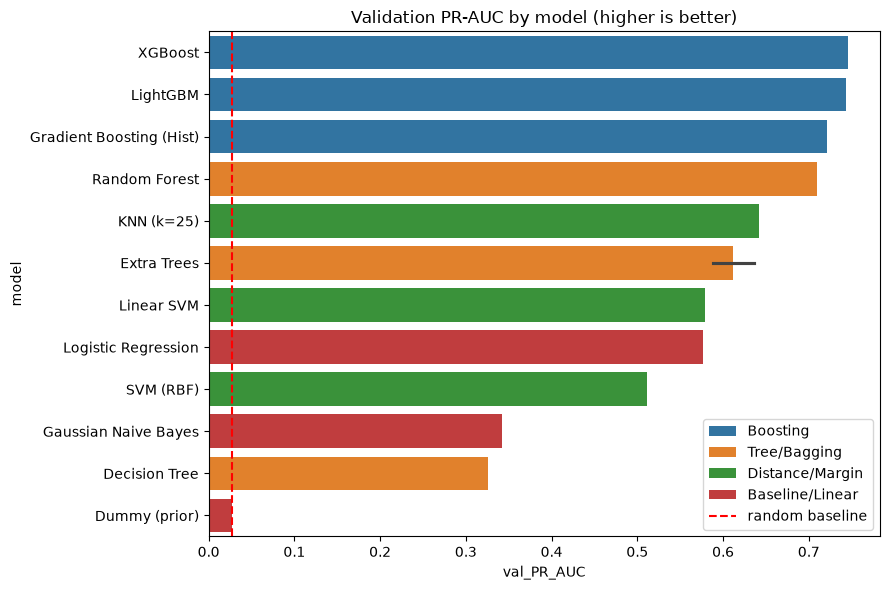

In [48]:
# ---- Leaderboard ----
res = pd.DataFrame(results).sort_values("val_PR_AUC", ascending=False).reset_index(drop=True)
res["gap(train-val PR-AUC)"] = res["train_PR_AUC"] - res["val_PR_AUC"]
display(res.round(4))

# Bar chart of PR-AUC
plt.figure(figsize=(9, 6))
sns.barplot(data=res, y="model", x="val_PR_AUC", hue="family", dodge=False)
plt.title("Validation PR-AUC by model (higher is better)")
plt.axvline(y_val.mean(), color="red", ls="--", label="random baseline")
plt.legend(); plt.tight_layout(); plt.show()

## 8. Overfitting analysis and treatment

**Why:** a model that scores far better on training data than on new data is memorising. We measure the gap and then reduce complexity.
**How:** compare train and validation PR-AUC, sweep Decision Tree depth with a minimum leaf size, plot the XGBoost learning curve with early stopping and regularisation, and vary `k` for KNN.

### 8.1 Decision Tree: depth sweep

The biggest fix is the **minimum leaf size**: requiring 20 users per leaf lifted the unconstrained tree from 0.326 to **0.643** validation PR-AUC (gap 0.67 to 0.17). A depth of about 15 keeps most of the gain with half the gap (0.079). Even the best tree stays well below boosting.

,max_depth,train_PR_AUC,val_PR_AUC,gap
0,2,0.2039,0.2005,0.0034
1,3,0.2264,0.2216,0.0049
2,4,0.3573,0.3565,0.0008
3,5,0.4351,0.4264,0.0087
4,6,0.4519,0.4438,0.0081
5,8,0.5389,0.5320,0.0070
6,10,0.5770,0.5515,0.0255
7,12,0.6339,0.5928,0.0411
8,15,0.7133,0.6339,0.0794
9,20,0.7731,0.6404,0.1327


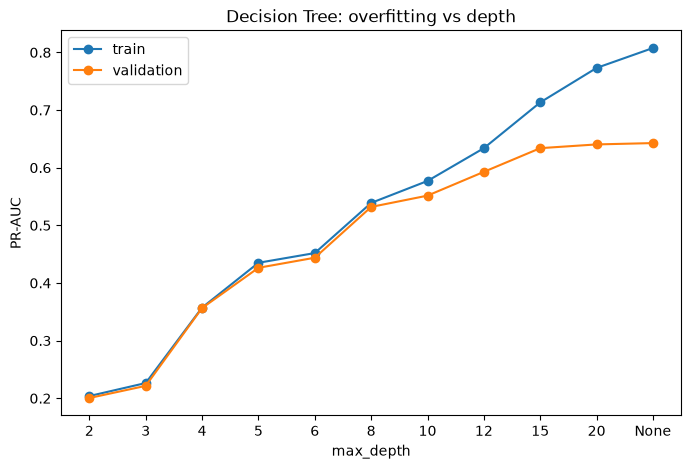

In [49]:
# ---- Train vs validation PR-AUC as tree depth grows ----
depths = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20, None]
rows = []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, min_samples_leaf=20,
                               class_weight="balanced", random_state=RANDOM_STATE).fit(XA_train, y_train)
    rows.append({
        "max_depth": "None" if d is None else d,
        "train_PR_AUC": average_precision_score(y_train, m.predict_proba(XA_train)[:, 1]),
        "val_PR_AUC":   average_precision_score(y_val,   m.predict_proba(XA_val)[:, 1]),
    })
dt_sweep = pd.DataFrame(rows)
dt_sweep["gap"] = dt_sweep["train_PR_AUC"] - dt_sweep["val_PR_AUC"]
display(dt_sweep.round(4))

plt.figure(figsize=(8, 5))
plt.plot(dt_sweep["max_depth"].astype(str), dt_sweep["train_PR_AUC"], marker="o", label="train")
plt.plot(dt_sweep["max_depth"].astype(str), dt_sweep["val_PR_AUC"], marker="o", label="validation")
plt.xlabel("max_depth"); plt.ylabel("PR-AUC"); plt.title("Decision Tree: overfitting vs depth")
plt.legend(); plt.show()

### 8.2 XGBoost: early stopping and regularisation

Using `subsample`, `colsample_bytree`, `min_child_weight`, `reg_lambda` and early stopping (best round **931**), validation PR-AUC rises from 0.746 to **0.757** (train 0.855, so a mild gap of about 0.10). The validation curve flattens and never turns downward. **Caveat:** early stopping uses the validation set, so this score is slightly optimistic; the test set gives the honest figure. The early-stopped model is added to the leaderboard below.

[0]	validation_0-aucpr:0.50361	validation_1-aucpr:0.48972
[100]	validation_0-aucpr:0.71825	validation_1-aucpr:0.69579
[200]	validation_0-aucpr:0.75624	validation_1-aucpr:0.72789
[300]	validation_0-aucpr:0.77782	validation_1-aucpr:0.73984
[400]	validation_0-aucpr:0.79308	validation_1-aucpr:0.74560
[500]	validation_0-aucpr:0.80769	validation_1-aucpr:0.74958
[600]	validation_0-aucpr:0.82096	validation_1-aucpr:0.75262
[700]	validation_0-aucpr:0.83242	validation_1-aucpr:0.75437
[800]	validation_0-aucpr:0.84188	validation_1-aucpr:0.75528
[900]	validation_0-aucpr:0.85175	validation_1-aucpr:0.75610
[981]	validation_0-aucpr:0.85888	validation_1-aucpr:0.75633
Best iteration: 931


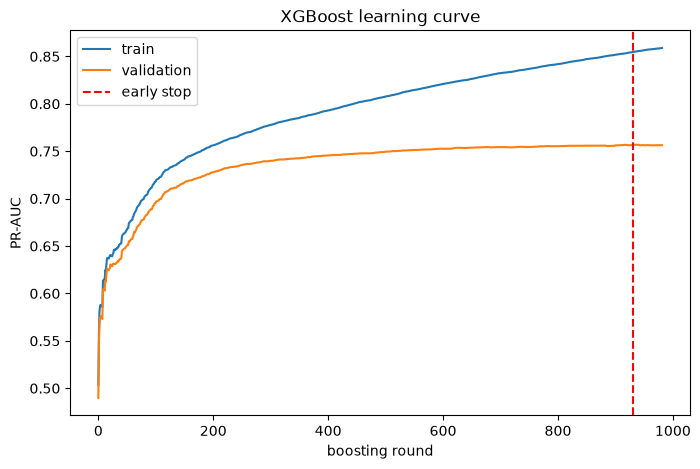

Train PR-AUC: 0.8547 | Val PR-AUC: 0.757


In [50]:
# ---- XGBoost with early stopping + regularization ----
xgb_es = XGBClassifier(
    n_estimators=1500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,       # random row/column sampling per tree
    min_child_weight=5, reg_lambda=5,          # regularization
    scale_pos_weight=spw, eval_metric="aucpr",
    early_stopping_rounds=50,                  # stop when validation stops improving
    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)

xgb_es.fit(XA_train, y_train,
           eval_set=[(XA_train, y_train), (XA_val, y_val)], verbose=100)

print("Best iteration:", xgb_es.best_iteration)

hist = xgb_es.evals_result()
plt.figure(figsize=(8, 5))
plt.plot(hist["validation_0"]["aucpr"], label="train")
plt.plot(hist["validation_1"]["aucpr"], label="validation")
plt.axvline(xgb_es.best_iteration, color="red", ls="--", label="early stop")
plt.xlabel("boosting round"); plt.ylabel("PR-AUC"); plt.legend()
plt.title("XGBoost learning curve"); plt.show()

s_tr = xgb_es.predict_proba(XA_train)[:, 1]; s_va = xgb_es.predict_proba(XA_val)[:, 1]
print("Train PR-AUC:", round(average_precision_score(y_train, s_tr), 4),
      "| Val PR-AUC:", round(average_precision_score(y_val, s_va), 4))

In [51]:
# Add the early-stopped XGBoost from the previous cell to the leaderboard
evaluate("XGBoost (early stop)", xgb_es, XA_train, y_train, XA_val, y_val, "Boosting", 0)

XGBoost (early stop)         PR-AUC=0.7570  F1=0.7313  (train PR-AUC=0.8612, 0s)


### 8.3 KNN: validation score against k

Validation PR-AUC: 0.315 at k = 1 (memorisation), 0.559 at k = 5, 0.619 at k = 25, **0.623 at k = 50**, 0.617 at k = 100. A classic bias-variance curve: larger `k` smooths the model.

In [52]:
# ---- KNN: validation score vs k (small k = overfit) ----
knn_rows = []
for k in [1, 5, 15, 25, 50, 100]:
    m = KNeighborsClassifier(n_neighbors=k, weights="uniform", n_jobs=-1).fit(sub60, ysub60)
    knn_rows.append({"k": k, "val_PR_AUC": average_precision_score(y_val, m.predict_proba(XB_val_s)[:, 1])})
display(pd.DataFrame(knn_rows).round(4))

,k,val_PR_AUC
0,1,0.3149
1,5,0.5586
2,15,0.6089
3,25,0.6194
4,50,0.6229
5,100,0.6172


## 9. Hyperparameter tuning, final model and test evaluation

**Why:** default settings are rarely optimal. Tuning uses 3-fold cross-validation **inside the training set**, so the validation set stays an independent check.
**How:** `RandomizedSearchCV` scored by average precision (PR-AUC): 15 candidates each for XGBoost and LightGBM, and 8 for Random Forest. The search over `scale_pos_weight` is included because full balancing is not always best for PR-AUC.

### 9.1 Tune XGBoost
Best CV PR-AUC 0.7579 (`max_depth` 8, `learning_rate` 0.05, 700 trees, `scale_pos_weight` 5). Validation PR-AUC 0.7663.

In [53]:
# ---- Tune XGBoost (3-fold CV on train; about 10 to 15 min) ----
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

param_xgb = {
    "max_depth": [4, 5, 6, 8],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [300, 500, 700],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 10, 20],
    "reg_lambda": [1, 5, 10, 20],
    "gamma": [0, 1, 5],
    "scale_pos_weight": [1, 5, round(spw ** 0.5, 1), round(spw, 1)],
}
search_xgb = RandomizedSearchCV(
    XGBClassifier(eval_metric="aucpr", tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE),
    param_xgb, n_iter=15, scoring="average_precision", cv=cv3,
    random_state=RANDOM_STATE, n_jobs=1, verbose=1)
t0 = time.time(); search_xgb.fit(XA_train, y_train)
print("Best params:", search_xgb.best_params_)
print("Best CV PR-AUC:", round(search_xgb.best_score_, 4), f"({time.time()-t0:.0f}s)")

evaluate("XGBoost (tuned)", search_xgb.best_estimator_, XA_train, y_train, XA_val, y_val,
         "Tuned", time.time() - t0)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'subsample': 0.7, 'scale_pos_weight': 5, 'reg_lambda': 1, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV PR-AUC: 0.7579 (624s)
XGBoost (tuned)              PR-AUC=0.7663  F1=0.7402  (train PR-AUC=0.9242, 624s)


### 9.2 Tune LightGBM
Best CV PR-AUC 0.7623 (`num_leaves` 63, `learning_rate` 0.03, 700 trees, `reg_lambda` 10, `scale_pos_weight` 1). Validation PR-AUC **0.7715**.

In [54]:
# ---- Tune LightGBM ----
param_lgb = {
    "num_leaves": [15, 31, 63, 127],
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [300, 500, 700],
    "subsample": [0.7, 0.8, 0.9], "subsample_freq": [1],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_samples": [20, 50, 100],
    "reg_lambda": [0, 5, 10, 20],
    "scale_pos_weight": [1, 5, round(spw ** 0.5, 1), round(spw, 1)],
}
search_lgb = RandomizedSearchCV(
    LGBMClassifier(n_jobs=-1, random_state=RANDOM_STATE, verbose=-1),
    param_lgb, n_iter=15, scoring="average_precision", cv=cv3,
    random_state=RANDOM_STATE, n_jobs=1, verbose=1)
t0 = time.time(); search_lgb.fit(XA_train, y_train)
print("Best params:", search_lgb.best_params_)
print("Best CV PR-AUC:", round(search_lgb.best_score_, 4))

evaluate("LightGBM (tuned)", search_lgb.best_estimator_, XA_train, y_train, XA_val, y_val,
         "Tuned", time.time() - t0)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'subsample_freq': 1, 'subsample': 0.8, 'scale_pos_weight': 1, 'reg_lambda': 10, 'num_leaves': 63, 'n_estimators': 700, 'min_child_samples': 50, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Best CV PR-AUC: 0.7623
LightGBM (tuned)             PR-AUC=0.7715  F1=0.7390  (train PR-AUC=0.8578, 578s)


### 9.3 Tune Random Forest
Best CV PR-AUC 0.7258; validation 0.7300 but a train-validation gap of 0.25 (it prefers unlimited depth and tiny leaves, which memorises). It took about 42 minutes, the most expensive model for a result below the boosters.

In [55]:
# WARNING: this search took about 42 minutes on our machine (24 fits of large forests).
# Lower n_iter (for example 3) or skip it if you only need the comparison.
# ---- Random Forest (re-run 7.3 first if RF/ET didn't finish) ----
param_rf = {
    "n_estimators": [200, 300],
    "max_depth": [15, 20, 30, None],
    "min_samples_leaf": [2, 5, 10, 20],
    "max_features": ["sqrt", 0.3, 0.5],
    "class_weight": ["balanced_subsample", None],
}
search_rf = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE),
    param_rf, n_iter=8, scoring="average_precision", cv=cv3,
    random_state=RANDOM_STATE, n_jobs=1, verbose=1)
t0 = time.time(); search_rf.fit(XA_train, y_train)
print("Best params:", search_rf.best_params_)
print("Best CV PR-AUC:", round(search_rf.best_score_, 4))

evaluate("Random Forest (tuned)", search_rf.best_estimator_, XA_train, y_train, XA_val, y_val,
         "Tuned", time.time() - t0)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'n_estimators': 300, 'min_samples_leaf': 2, 'max_features': 0.3, 'max_depth': None, 'class_weight': None}
Best CV PR-AUC: 0.7258
Random Forest (tuned)        PR-AUC=0.7300  F1=0.7095  (train PR-AUC=0.9831, 2525s)


### 9.4 Final leaderboard (validation)

**LightGBM (tuned) is chosen**: highest PR-AUC (0.7715 against 0.7663 for XGBoost tuned), a much smaller train-validation gap (0.086 against 0.158) and faster training. The two boosters are close, so these three reasons justify the choice.

In [56]:
# ---- Final leaderboard on validation ----
res = pd.DataFrame(results).sort_values("val_PR_AUC", ascending=False).reset_index(drop=True)
res["gap"] = res["train_PR_AUC"] - res["val_PR_AUC"]
display(res[["model", "family", "val_PR_AUC", "val_ROC_AUC", "precision", "recall", "F1", "gap", "fit_sec"]].round(4))
res.to_csv("model_leaderboard.csv", index=False)   # keep a copy for the report

,model,family,val_PR_AUC,val_ROC_AUC,precision,recall,F1,gap,fit_sec
0,LightGBM (tuned),Tuned,0.7715,0.9663,0.8143,0.6764,0.7390,0.0863,578.3440
1,XGBoost (tuned),Tuned,0.7663,0.9641,0.7933,0.6937,0.7402,0.1579,624.4942
2,XGBoost (early stop),Boosting,0.7570,0.9644,0.8146,0.6634,0.7313,0.1042,0.0000
3,XGBoost,Boosting,0.7457,0.9627,0.7854,0.6715,0.7240,0.0817,8.9906
4,LightGBM,Boosting,0.7437,0.9637,0.7887,0.6564,0.7165,0.0745,5.3187
5,Random Forest (tuned),Tuned,0.7300,0.9521,0.8308,0.6190,0.7095,0.2531,2524.9826
6,Gradient Boosting (Hist),Boosting,0.7211,0.9618,0.7780,0.6277,0.6948,0.0288,8.4063
7,Random Forest,Tree/Bagging,0.7093,0.9545,0.8028,0.5969,0.6847,0.1914,57.1784
8,KNN (k=25),Distance/Margin,0.6413,0.9003,0.6899,0.5936,0.6382,0.3587,0.0207
9,Extra Trees,Tree/Bagging,0.6356,0.9430,0.6634,0.5877,0.6232,0.1886,66.2988


### 9.5 One-time evaluation on the test set

The winner is evaluated **once** on the untouched test set using the threshold selected on validation (0.3762).
**Result:** test PR-AUC **0.7818**, ROC-AUC **0.9703**; for spammers precision 0.813, recall 0.691, F1 0.747. Test scores match validation, so tuning did not overfit the validation set. Accuracy (98.7%) is not the headline figure.

Model: LightGBM (tuned) | threshold: 0.3762
Test PR-AUC : 0.7818
Test ROC-AUC: 0.9703
              precision    recall  f1-score   support

 Non-spammer     0.9915    0.9956    0.9936     66972
     Spammer     0.8134    0.6910    0.7472      1848

    accuracy                         0.9874     68820
   macro avg     0.9024    0.8433    0.8704     68820
weighted avg     0.9867    0.9874    0.9869     68820



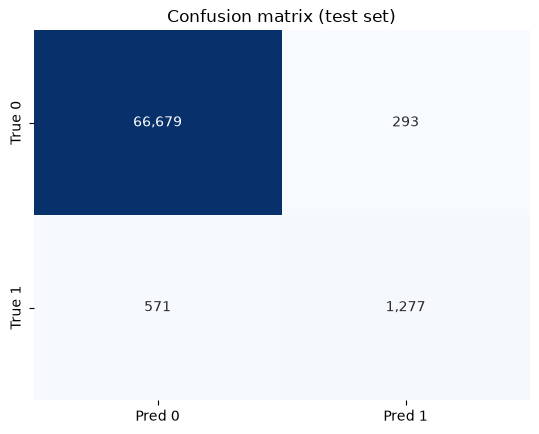

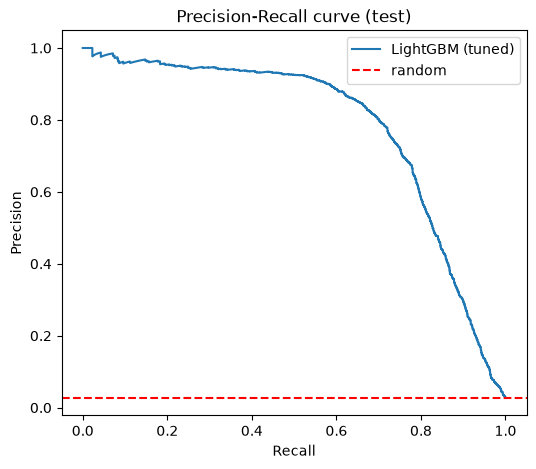

In [57]:
# ---- ONE-TIME evaluation of the winner on the test set ----
# Replace the name below with the best model in the 9.4 leaderboard.
best_name = res.loc[0, "model"]
best_model = fitted[best_name]
thr = res.loc[0, "threshold"]                       # chosen on VALIDATION, not on test

s_test = best_model.predict_proba(XA_test)[:, 1]
pred = (s_test >= thr).astype(int)

print("Model:", best_name, "| threshold:", round(thr, 4))
print("Test PR-AUC :", round(average_precision_score(y_test, s_test), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, s_test), 4))
print(classification_report(y_test, pred, target_names=["Non-spammer", "Spammer"], digits=4))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("Confusion matrix (test set)"); plt.show()

p, r, _ = precision_recall_curve(y_test, s_test)
plt.figure(figsize=(6, 5)); plt.plot(r, p, label=best_name)
plt.axhline(y_test.mean(), color="red", ls="--", label="random")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall curve (test)")
plt.legend(); plt.show()

### 9.6 Feature importance (by gain)

Importance by gain is the share of total loss reduction each feature contributes (split counts would favour columns with many distinct values). **`X19` alone carries about 34.5%**, and the seven code columns (`X2` to `X8`) together about 34.3%. Importance shows what the model uses, not why users spam; the columns are anonymised.

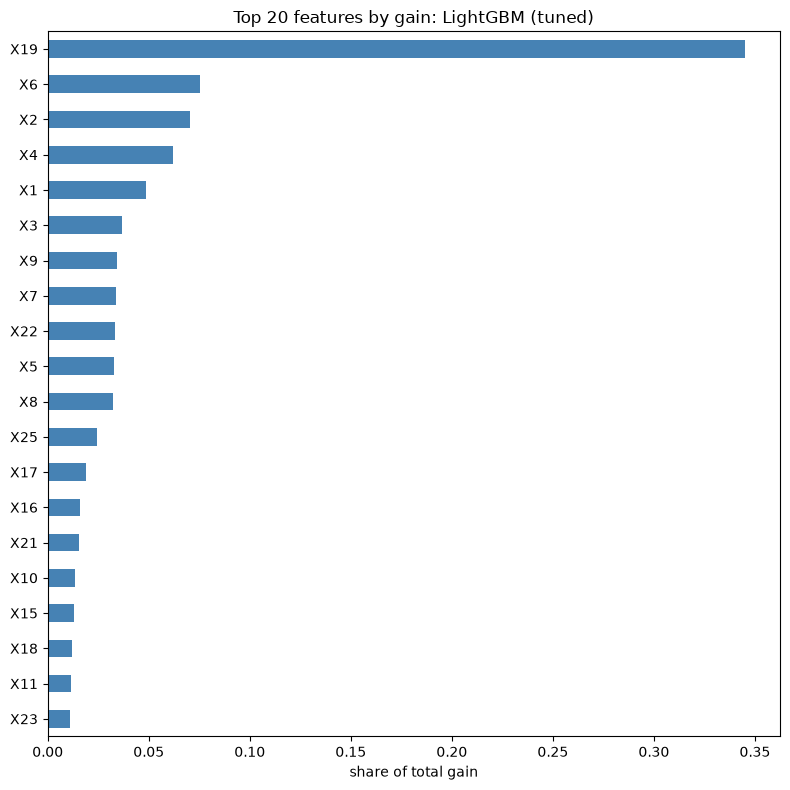

X19    0.3451
X6     0.0751
X2     0.0702
X4     0.0618
X1     0.0486
X3     0.0367
X9     0.0340
X7     0.0337
X22    0.0331
X5     0.0329
X8     0.0323
X25    0.0243
X17    0.0189
X16    0.0160
X21    0.0154
dtype: float64


In [63]:
# ---- Feature importance by gain (LightGBM) ----
best_model = fitted["LightGBM (tuned)"]          # make sure it's the LightGBM model
imp = pd.Series(best_model.booster_.feature_importance(importance_type="gain"),
                index=XA_train.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)

plt.figure(figsize=(8, 8)); imp.head(20)[::-1].plot(kind="barh", color="steelblue")
plt.title("Top 20 features by gain: LightGBM (tuned)"); plt.xlabel("share of total gain")
plt.tight_layout(); plt.show()
print(imp.head(15).round(4))

## 10. Threshold trade-off, saving the model, and files for the Streamlit app

### 10.1 Threshold trade-off (test set)

The decision threshold can be moved depending on the business use. F1 is flat between 0.30 and 0.38. Use a low threshold (0.10: recall 0.81, precision 0.55) for a manual review queue and a high one (0.80: precision 0.93, recall 0.48) for automatic blocking. The official threshold stays at **0.3762**, chosen on validation; choosing a new one from test results would make the test score optimistic.

In [59]:
# ---- Precision/recall trade-off on the TEST set ----
rows = []
for thr_ in [0.10, 0.20, 0.30, 0.3762, 0.50, 0.60, 0.70, 0.80]:
    pr = (s_test >= thr_).astype(int)
    rows.append({"threshold": thr_,
                 "flagged_users": int(pr.sum()),
                 "precision": precision_score(y_test, pr),
                 "recall": recall_score(y_test, pr),
                 "F1": f1_score(y_test, pr)})
display(pd.DataFrame(rows).round(4))

,threshold,flagged_users,precision,recall,F1
0,0.1000,2712,0.5524,0.8106,0.6570
1,0.2000,2034,0.6932,0.7630,0.7264
2,0.3000,1723,0.7731,0.7208,0.7460
3,0.3762,1569,0.8133,0.6905,0.7469
4,0.5000,1363,0.8621,0.6358,0.7319
5,0.6000,1232,0.8912,0.5942,0.7130
6,0.7000,1116,0.9131,0.5514,0.6876
7,0.8000,965,0.9275,0.4843,0.6363


### 10.2 Save the final model
The model, threshold, feature list, dropped columns and parameters are saved for the app.

In [60]:
# ---- Save the final model and settings ----
joblib.dump(best_model, "lightgbm_spammer_model.pkl")
meta = {
    "model": "LightGBM (tuned)",
    "threshold": float(thr),
    "features": XA_train.columns.tolist(),
    "dropped_columns": ['X27','X29','X30','X33','X46','X47','X48','X51','X35'],
    "extra_feature": "X10_is_1 = (X10 == 1)",
    "test_PR_AUC": float(average_precision_score(y_test, s_test)),
    "test_ROC_AUC": float(roc_auc_score(y_test, s_test)),
    "best_params": search_lgb.best_params_,
}
with open("model_metadata.json", "w") as f:
    json.dump(meta, f, indent=2, default=str)
print("Saved model and metadata.")

Saved model and metadata.


### 10.3 Score all users
Demonstrates the scoring pipeline on every user. This includes training users, so it is **not** a performance estimate.

In [61]:
# NOTE: this includes users the model was trained on, so it only demonstrates the scoring
# pipeline. Report performance from the held-out TEST set only.
# ---- Score every user (risk list) ----
all_X = add_flags(df_clean.drop(columns=["label", "user_id"]))[XA_train.columns]
out = pd.DataFrame({"user_id": df_clean["user_id"].values,
                    "spam_probability": best_model.predict_proba(all_X)[:, 1]})
out["predicted_spammer"] = (out["spam_probability"] >= thr).astype(int)
out.to_csv("spammer_predictions.csv", index=False)
print(out["predicted_spammer"].value_counts())
display(out.sort_values("spam_probability", ascending=False).head(10))

predicted_spammer
0    448198
1     10600
Name: count, dtype: int64


,user_id,spam_probability,predicted_spammer
435240,458071,0.995229,1
302920,318863,0.994134,1
288697,303761,0.993768,1
432496,455164,0.993519,1
299637,315373,0.993182,1
310126,326572,0.993162,1
287498,302471,0.993151,1
303032,318975,0.993063,1
302787,318730,0.992662,1
293827,309188,0.992540,1


### 10.4 Reload check
The saved model reproduces the test PR-AUC (0.7818).

In [62]:
# ---- Quick sanity check that the saved model reloads ----
m2 = joblib.load("lightgbm_spammer_model.pkl")
print("Reloaded model reproduces test PR-AUC:",
      round(average_precision_score(y_test, m2.predict_proba(XA_test)[:, 1]), 4))

Reloaded model reproduces test PR-AUC: 0.7818


### 10.5 Files for the Streamlit app
Saves training medians and ranges (`feature_defaults.json`) and a 300-row demo file (`sample_users.csv`). Then run `streamlit run app.py` from this folder.

In [64]:
# ---- Files for the Streamlit app ----
raw_cols = X_train.columns.tolist()                      # the 42 raw feature columns
info = {
    "raw_columns": raw_cols,
    "defaults": X_train.median().to_dict(),              # training medians
    "ranges": {c: [float(X_train[c].min()), float(X_train[c].max())] for c in raw_cols},
}
with open("feature_defaults.json", "w") as f:
    json.dump(info, f, default=float, indent=2)

# Demo file: 100 spammers + 200 non-spammers from the TEST set, with user_id and label
demo_idx = pd.concat([
    y_test[y_test == 1].sample(100, random_state=RANDOM_STATE),
    y_test[y_test == 0].sample(200, random_state=RANDOM_STATE),
]).index
demo = X_test.loc[demo_idx].copy()
demo.insert(0, "user_id", df_clean.loc[demo_idx, "user_id"].values)
demo["label"] = y_test.loc[demo_idx].values
demo.sample(frac=1, random_state=RANDOM_STATE).to_csv("sample_users.csv", index=False)

print(len(raw_cols), "raw columns saved |", demo.shape, "demo rows")

42 raw columns saved | (300, 44) demo rows


## 11. Conclusion

A tuned **LightGBM** classifier identifies potential Fiverr spammers with a test **PR-AUC of 0.782** and ROC-AUC of 0.970 (a random model scores 0.027), catching about **69% of spammers with 81% precision** at the chosen threshold. Tree-based boosting clearly outperformed linear, distance-based and probabilistic models because the signal is non-linear and concentrated in a few behaviours (notably `X19`) and user segments (the code columns).

**Limitations:** about 41% of spammers have `X19 = 0` and must be found through other features, which caps recall; 726 users sit in groups of identical behaviour with mixed labels; only one labeled file was available, so a stratified hold-out test set was created; the columns are anonymised, so the findings are statistical patterns and not explained behaviours; early stopping used the validation set.

**Future work:** probability calibration, resampling (SMOTE), ensembling LightGBM and XGBoost, time-based validation if sign-up dates become available, and drift monitoring.